In [1]:
import torch
import os
import numpy as np
import pandas as pd
import math

In [2]:
root_cub = os.path.join("experiments", "scbm_residual", "CUB")

# # 50 residuals
# EXPERIMENT_PATH = os.path.join(root_cub, "Mateo_025_fixed_emp_perc_L_int_extension_loss_weight_1_2026-07-30_17-04-11_72f02")

# # 20 residuals
EXPERIMENT_PATH = os.path.join(root_cub, "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-07-31_20-15-47_174e5")

# 5 residuals
# EXPERIMENT_PATH = os.path.join(root_cub, "Mateo_025_fixed_emp_perc_residuals_5_L_int_extension_loss_weight_1_2026-07-31_20-15-47_496cf")



## Dataset information

In [3]:
ATTRIBUTES_IDX_USED = [1, 4, 6, 7, 10, 14, 15, 20, 21, 23, 25, 29, 30, 35, 36, 38, 40, 44, 45, 50, 51, 53, 54, 56, 57, 59, 63, 64, 69, 70, 72, 75, 80, 84, 90, 91, \
    93, 99, 101, 106, 110, 111, 116, 117, 119, 125, 126, 131, 132, 134, 145, 149, 151, 152, 153, 157, 158, 163, 164, 168, 172, 178, 179, 181, \
    183, 187, 188, 193, 194, 196, 198, 202, 203, 208, 209, 211, 212, 213, 218, 220, 221, 225, 235, 236, 238, 239, 240, 242, 243, 244, 249, 253, \
    254, 259, 260, 262, 268, 274, 277, 283, 289, 292, 293, 294, 298, 299, 304, 305, 308, 309, 310, 311]

with open(os.path.join("datasets", "CUB", "CUB_200_2011", "attributes.txt"), 'r') as f:
    all_attributes_orig_idx = {}
    
    lines = f.readlines()
    for line in lines:
        idx, attr_name = line.strip().split(" ")
        #attr_group, attr_name = attr_name.split("::")  
        # 0-based indexing
        all_attributes_orig_idx[int(idx) - 1] = attr_name
  
# Map between 112 concept idx and attribute name      
sample_112_concepts_map = {new_idx: all_attributes_orig_idx[orig_idx] for new_idx, orig_idx in enumerate(ATTRIBUTES_IDX_USED)}
attr_groups__112_concepts = list(set(attr_name.split("::")[0] for attr_name in sample_112_concepts_map.values()))

print(sample_112_concepts_map)
print(attr_groups__112_concepts)
print(len(attr_groups__112_concepts))


{0: 'has_bill_shape::dagger', 1: 'has_bill_shape::hooked_seabird', 2: 'has_bill_shape::all-purpose', 3: 'has_bill_shape::cone', 4: 'has_wing_color::brown', 5: 'has_wing_color::grey', 6: 'has_wing_color::yellow', 7: 'has_wing_color::black', 8: 'has_wing_color::white', 9: 'has_wing_color::buff', 10: 'has_upperparts_color::brown', 11: 'has_upperparts_color::grey', 12: 'has_upperparts_color::yellow', 13: 'has_upperparts_color::black', 14: 'has_upperparts_color::white', 15: 'has_upperparts_color::buff', 16: 'has_underparts_color::brown', 17: 'has_underparts_color::grey', 18: 'has_underparts_color::yellow', 19: 'has_underparts_color::black', 20: 'has_underparts_color::white', 21: 'has_underparts_color::buff', 22: 'has_breast_pattern::solid', 23: 'has_breast_pattern::striped', 24: 'has_breast_pattern::multi-colored', 25: 'has_back_color::brown', 26: 'has_back_color::grey', 27: 'has_back_color::yellow', 28: 'has_back_color::black', 29: 'has_back_color::white', 30: 'has_back_color::buff', 31: '

In [4]:
# Read dataset dir from the log file in the experiment path
import ast


info_dataset_path = os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", "info.txt")


with open(info_dataset_path, 'r') as f:
    lines = f.readlines()

    for line in lines:
        if "New attribute indices mapping: " in line:
            new_attribute_mapping_string = line.split("New attribute indices mapping: ")[1].strip()
            
        if "Removed attribute groups: " in line:
            removed_attribute_groups_string = line.split("Removed attribute groups: ")[1].strip()
            

# Original has 112 attributes, but we only use a subset of them
new_attribute_mapping = ast.literal_eval(new_attribute_mapping_string)

# Removed groups list
removed_attribute_groups = ast.literal_eval(removed_attribute_groups_string)
    

        
        
concept_names_new_idx_map = {}
for orig_idx, new_idx in new_attribute_mapping.items():
    concept_names_new_idx_map[new_idx] = sample_112_concepts_map[orig_idx]


df = pd.DataFrame(list(concept_names_new_idx_map.items()), columns=['New Index', 'Concept Name'])
display(df.sort_values(by='New Index').reset_index(drop=True))

# Number of attrbutes removed
print(f"Number of attributes removed: {112 - len(concept_names_new_idx_map.keys())}")



,New Index,Concept Name
0,0,has_bill_shape::dagger
1,1,has_bill_shape::hooked_seabird
2,2,has_bill_shape::all-purpose
3,3,has_bill_shape::cone
4,4,has_head_pattern::eyebrow
5,5,has_head_pattern::plain
6,6,has_breast_color::brown
7,7,has_breast_color::grey
8,8,has_breast_color::yellow
9,9,has_breast_color::black


Number of attributes removed: 90


### Missing concepts 

In [5]:


missing_concept_names = [sample_112_concepts_map[orig_idx] for orig_idx in range(112) if orig_idx not in new_attribute_mapping.keys()]
print(missing_concept_names)

['has_wing_color::brown', 'has_wing_color::grey', 'has_wing_color::yellow', 'has_wing_color::black', 'has_wing_color::white', 'has_wing_color::buff', 'has_upperparts_color::brown', 'has_upperparts_color::grey', 'has_upperparts_color::yellow', 'has_upperparts_color::black', 'has_upperparts_color::white', 'has_upperparts_color::buff', 'has_underparts_color::brown', 'has_underparts_color::grey', 'has_underparts_color::yellow', 'has_underparts_color::black', 'has_underparts_color::white', 'has_underparts_color::buff', 'has_breast_pattern::solid', 'has_breast_pattern::striped', 'has_breast_pattern::multi-colored', 'has_back_color::brown', 'has_back_color::grey', 'has_back_color::yellow', 'has_back_color::black', 'has_back_color::white', 'has_back_color::buff', 'has_tail_shape::notched_tail', 'has_upper_tail_color::brown', 'has_upper_tail_color::grey', 'has_upper_tail_color::black', 'has_upper_tail_color::white', 'has_upper_tail_color::buff', 'has_throat_color::grey', 'has_throat_color::yell

Use this to check if some residuals get more activated with some hidden concepts

### Check that the attribute groups in the above df is the same as the attribute groups kept for data generation

This is a security check


In [6]:
# Check if the concept name in the df matches the attribute groups that were used: attr_groups_unique
attr_groups_from_df = df["Concept Name"].apply(lambda name: name.split("::")[0])

attr_groups_from_df = list(attr_groups_from_df.unique())


kept_attr_groups_from_info = [group for group in attr_groups__112_concepts if group not in removed_attribute_groups]

# Check if the kept attribute groups from the info file match the attribute groups from the df
print(f"same attribute groups: {set(kept_attr_groups_from_info) == set(attr_groups_from_df)}")


same attribute groups: True


## Residual channel analysis

In [7]:
# Print out test and test concepts and residuals probabilities and binary samples
split = "train"
c_r_probs = torch.load(os.path.join(EXPERIMENT_PATH, split, "concepts_residuals_pred_probs_mean.pt"))
c_r_binarized = (c_r_probs > 0.5).float()  # Binarize the probabilities
y_true = torch.load(os.path.join(EXPERIMENT_PATH, split, "y_true.pt"))
c_r_logits = torch.load(os.path.join(EXPERIMENT_PATH, split, "concepts_residuals_logits_mean.pt"))


print("c_r_probs shape:", c_r_probs.shape)
print("c_r_bin shape:", c_r_binarized.shape)


# Get unique values and their counts for each concept and residual)
unique_probs, counts_probs = torch.unique(c_r_probs, return_counts=True)
unique_bin, counts_bin = torch.unique(c_r_binarized, return_counts=True)


print("Unique binary samples and their counts:")
for u, c in zip(unique_bin, counts_bin):
    print(f"  {u}: {c}")

c_r_probs shape: torch.Size([4796, 42])
c_r_bin shape: torch.Size([4796, 42])
Unique binary samples and their counts:
  0.0: 123043
  1.0: 78389


### Distributions of concept and residual probabilities

tensor([[1.4376e-08, 1.2122e-05, 6.2639e-08,  ..., 4.6319e-02, 1.1388e-04,
         1.7494e-03],
        [9.9210e-06, 7.2605e-05, 2.1172e-03,  ..., 1.0000e+00, 6.4511e-02,
         2.0019e-03],
        [5.5405e-07, 2.2207e-05, 3.1783e-10,  ..., 1.0000e+00, 2.1398e-06,
         9.9999e-01],
        ...,
        [1.6779e-03, 1.1464e-04, 3.7481e-01,  ..., 9.3126e-01, 8.3295e-01,
         4.5548e-01],
        [1.3296e-04, 2.4321e-03, 9.9545e-01,  ..., 9.9776e-01, 9.9066e-01,
         9.4255e-01],
        [1.1450e-06, 3.1452e-06, 9.9899e-01,  ..., 4.8285e-06, 4.9644e-06,
         9.9998e-01]])


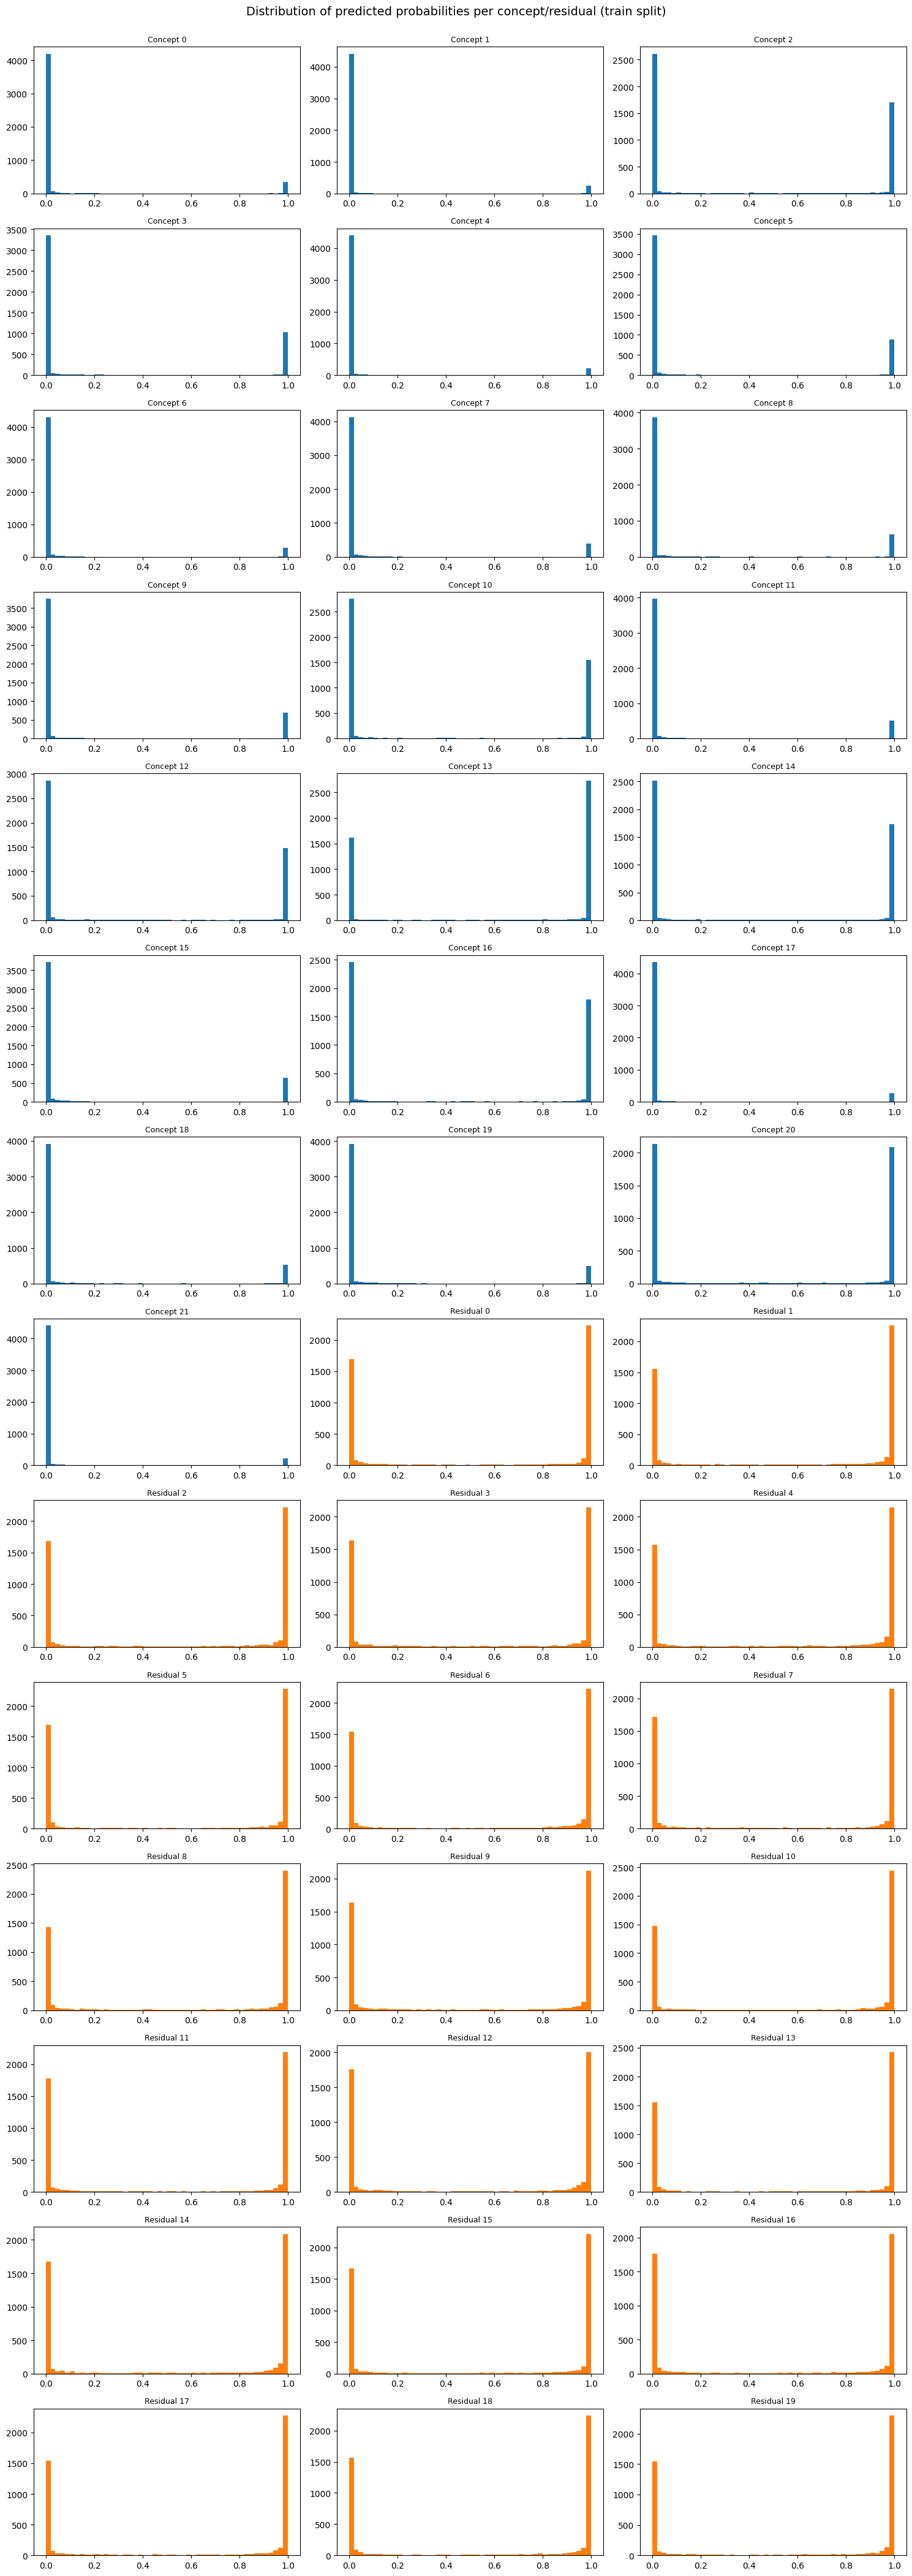

In [8]:
print(c_r_probs)
# Plot distribtion of probabilities for each concept and residual
# Plot individually for each concept and residual where you have three plots per row
import matplotlib.pyplot as plt
import math

num_concepts = 22
num_dims = c_r_probs.shape[1]
num_cols = 3
num_rows = math.ceil(num_dims / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(num_dims):
    ax = axes[i]
    is_concept = i < num_concepts
    label = f"Concept {i}" if is_concept else f"Residual {i - num_concepts}"
    ax.hist(c_r_probs[:, i].numpy(), bins=50, range=(0, 1), color="tab:blue" if is_concept else "tab:orange")
    ax.set_title(label, fontsize=9)

# Hide any unused axes
for ax in axes[num_dims:]:
    ax.axis("off")

fig.suptitle(f"Distribution of predicted probabilities per concept/residual ({split} split)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

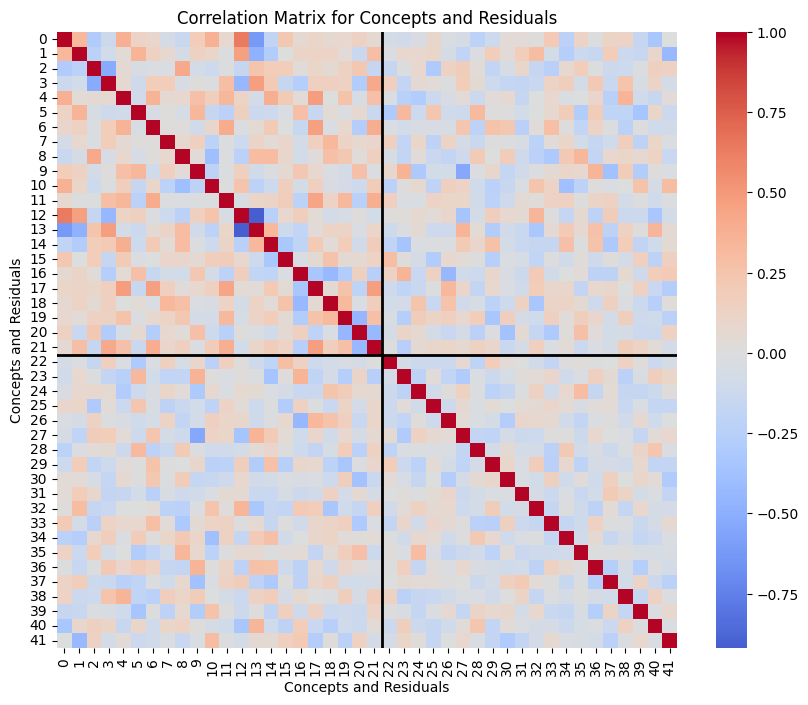

In [9]:
# Plot correlation matrix for concepts and residuals
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix
corr_matrix = torch.corrcoef(c_r_logits.t())
# Draw lines to split the concepts and residuals in the correlation matrix
num_concepts = 22  # Adjust this based on your actual number of concepts


# Plot correlation matrix
plt.figure(figsize=(10, 8))
plt.axhline(y=num_concepts, color='black', linewidth=2)
plt.axvline(x=num_concepts, color='black', linewidth=2)
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix for Concepts and Residuals')
plt.xlabel('Concepts and Residuals')
plt.ylabel('Concepts and Residuals')
plt.show()

In [10]:
# Entropy calculation for each concept and residual
def calculate_entropy(probs):
    # Ensure probabilities are in the range (0, 1)
    probs = torch.clamp(probs, min=1e-10, max=1-1e-10)
    return -torch.sum(probs * torch.log(probs) + (1 - probs) * torch.log(1 - probs), dim=0)

# Print entropy for each concept and residual
entropy_values = calculate_entropy(c_r_probs)

# Make this into dataframe with columns: concept/residual, entropy, variation, active_count, inactive_count, ratio_active_inactive
data = []
variation_logits = torch.var(c_r_logits, dim=0)
active_counts = torch.sum(c_r_binarized, dim=0)
inactive_counts = c_r_binarized.shape[0] - active_counts
ratio_active_inactive = active_counts / (inactive_counts + active_counts + 1e-10)

# Also add most correlated residual for each concept and vice versa, and the correlation value
for i in range(c_r_binarized.shape[1]):
    if i < 22:
        data.append({
            "concept/residual": f"Concept {i}",
            "entropy": entropy_values[i].item(),
            "variance logits": variation_logits[i].item(),
            "active_count": active_counts[i].item(),
            "inactive_count": inactive_counts[i].item(),
            "ratio_active_inactive": ratio_active_inactive[i].item(),
            "most correlated residual": f"Residual {torch.argmax(corr_matrix[i, 22:]).item()}",
            "correlation value": corr_matrix[i, 22 + torch.argmax(corr_matrix[i, 22:])].item()
        })
    else:
        data.append({
            "concept/residual": f"Residual {i-22}",
            "entropy": entropy_values[i].item(),
            "variance logits": variation_logits[i].item(),
            "active_count": active_counts[i].item(),
            "inactive_count": inactive_counts[i].item(),
            "ratio_active_inactive": ratio_active_inactive[i].item(),
            "most correlated concept": f"Concept {torch.argmax(corr_matrix[i, :22]).item()}",
            "correlation value": corr_matrix[i, torch.argmax(corr_matrix[i, :22])].item()
        })
        
import pandas as pd
df = pd.DataFrame(data)
# dislay all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df)

,concept/residual,entropy,variance logits,active_count,inactive_count,ratio_active_inactive,most correlated residual,correlation value,most correlated concept
0,Concept 0,NaN,100.907387,390.0,4406.0,0.081318,Residual 11,0.210643,NaN
1,Concept 1,NaN,60.984955,285.0,4511.0,0.059425,Residual 10,0.298348,NaN
2,Concept 2,NaN,166.640701,1936.0,2860.0,0.403670,Residual 13,0.177354,NaN
3,Concept 3,NaN,145.530441,1139.0,3657.0,0.237490,Residual 16,0.252487,NaN
4,Concept 4,NaN,69.835251,229.0,4567.0,0.047748,Residual 16,0.351303,NaN
5,Concept 5,NaN,100.930016,1007.0,3789.0,0.209967,Residual 1,0.318907,NaN
6,Concept 6,NaN,55.599777,299.0,4497.0,0.062344,Residual 11,0.285010,NaN
7,Concept 7,NaN,65.691681,419.0,4377.0,0.087364,Residual 16,0.165191,NaN
8,Concept 8,NaN,81.157059,684.0,4112.0,0.142619,Residual 13,0.336451,NaN
9,Concept 9,NaN,86.386749,773.0,4023.0,0.161176,Residual 1,0.357250,NaN


# Plot the distributions

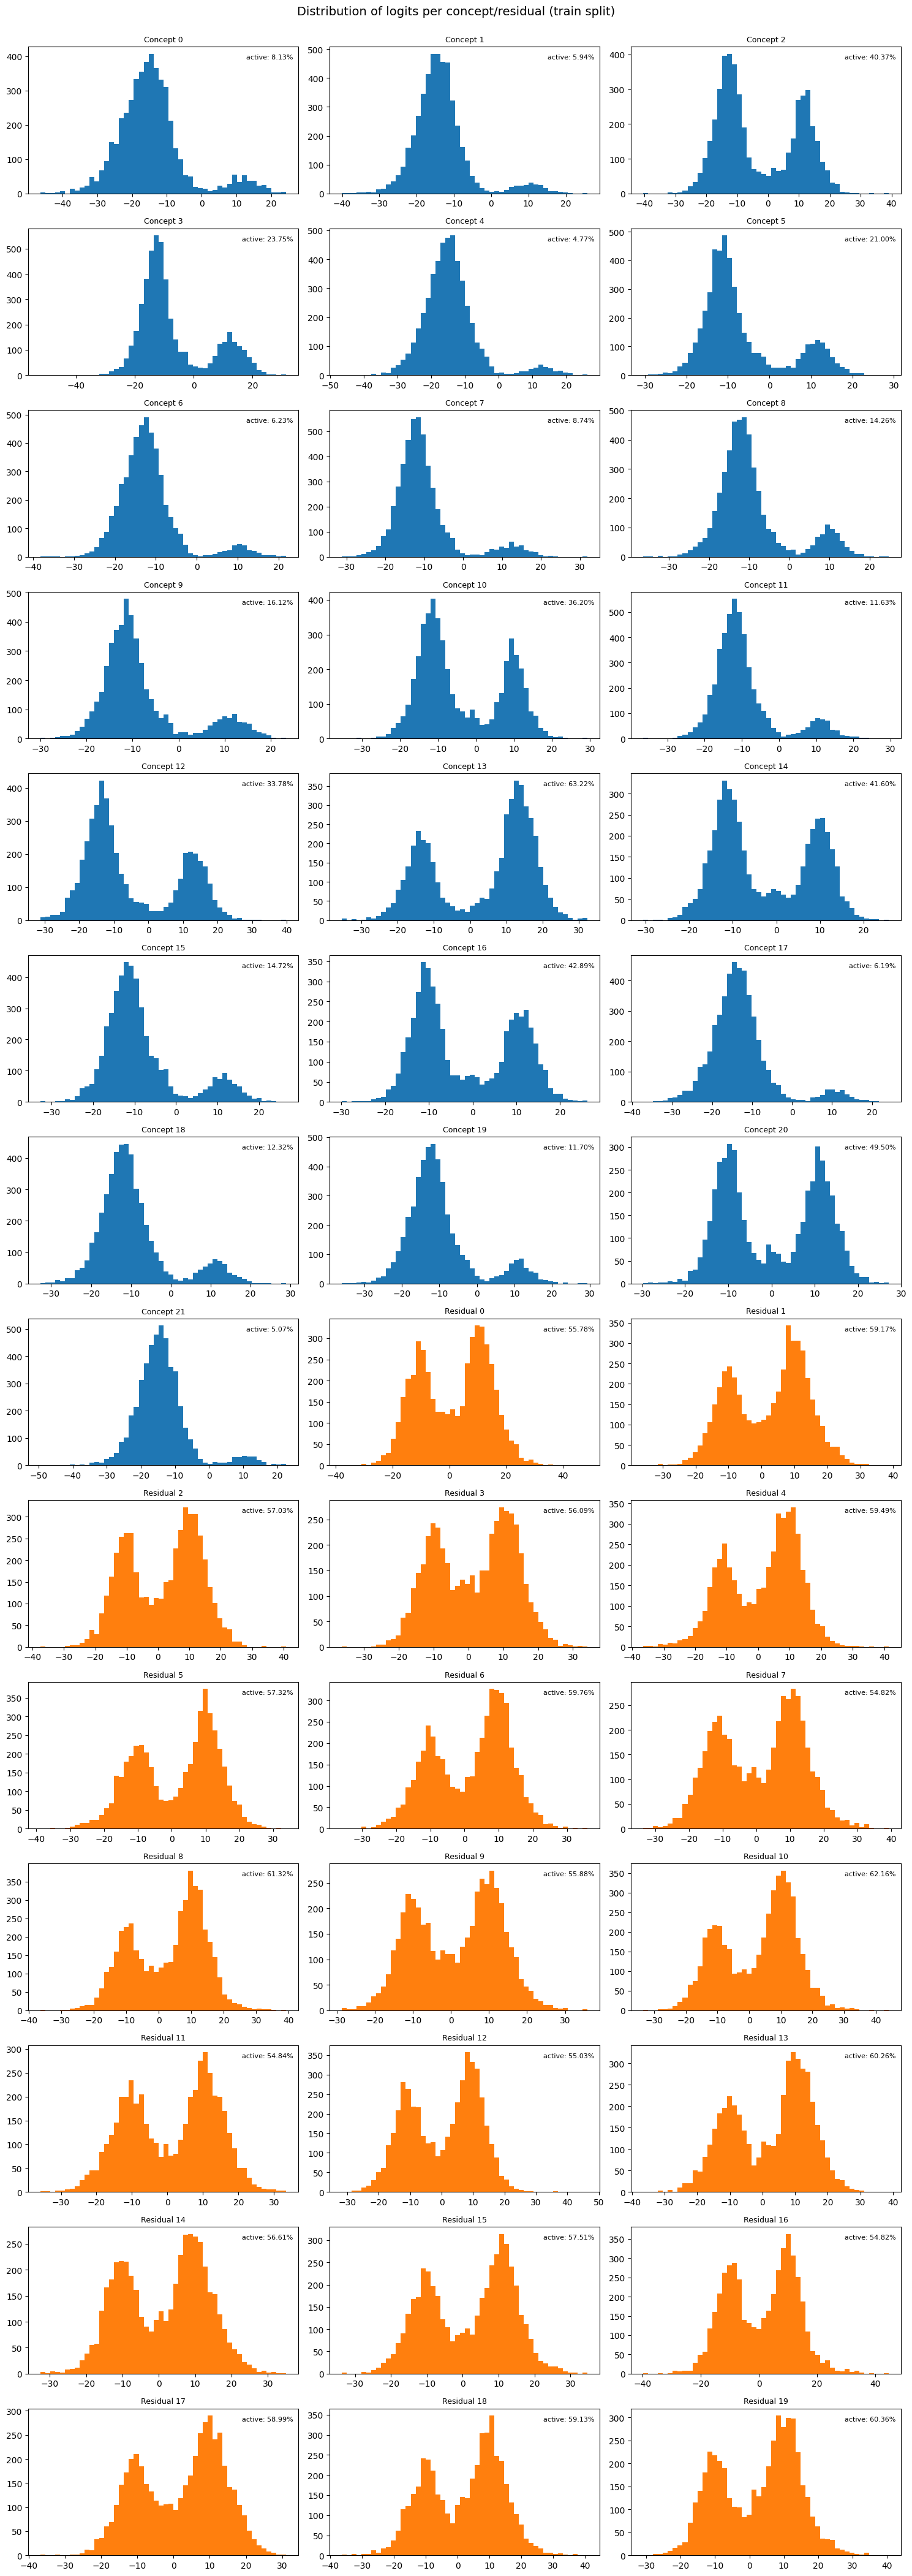

In [11]:
import matplotlib.pyplot as plt
import math

# Plot the logit distribution of every concept and residual in one figure, 3 per row,
# annotated with each dimension's activation rate (fraction of samples with prob > 0.5)
num_concepts = 22
num_dims = c_r_logits.shape[1]
num_cols = 3
num_rows = math.ceil(num_dims / num_cols)

activation_rates = c_r_binarized.mean(dim=0)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(num_dims):
    ax = axes[i]
    is_concept = i < num_concepts
    label = f"Concept {i}" if is_concept else f"Residual {i - num_concepts}"
    ax.hist(c_r_logits[:, i].numpy(), bins=50, color="tab:blue" if is_concept else "tab:orange")
    ax.set_title(label, fontsize=9)
    ax.text(
        0.98, 0.95,
        f"active: {activation_rates[i].item():.2%}",
        transform=ax.transAxes,
        ha="right", va="top", fontsize=8,
    )

# Hide any unused axes
for ax in axes[num_dims:]:
    ax.axis("off")

fig.suptitle(f"Distribution of logits per concept/residual ({split} split)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

## Concept & residual activation by class

In [12]:
num_concepts = 22
num_residuals = c_r_probs.shape[1] - num_concepts
dim_names = list(range(c_r_probs.shape[1]))  # 0..21 concepts, 22..71 residuals
class_names = list(range(200))

print(f"{num_concepts} concepts, {num_residuals} residuals, {len(class_names)} classes")

22 concepts, 20 residuals, 200 classes


In [13]:
# Mean predicted activation probability of each concept/residual, per ground-truth class.
# the global y_true with the test split's version as a side effect.
y_true = torch.load(os.path.join(EXPERIMENT_PATH, split, "y_true.pt"))

df_dims = pd.DataFrame(c_r_probs.numpy(), columns=dim_names)
df_dims["class"] = y_true.numpy()
class_means = df_dims.groupby("class").mean()
class_means.index = [class_names[i] for i in class_means.index]

print("class_means shape:", class_means.shape)
class_means.head()

class_means shape: (200, 42)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41
0,0.000004,0.995912,0.000065,0.004517,0.000003,0.000041,0.000218,0.000546,0.000053,0.000160,0.000038,0.007377,0.994002,0.000736,0.000124,0.000538,0.987432,0.000014,0.000031,0.000031,0.008789,0.000310,0.998814,0.994343,0.985168,0.992122,0.003944,0.118111,0.025741,0.998302,0.983566,0.999948,0.999749,0.000039,0.002634,0.999832,0.020440,0.998670,0.002281,0.987959,0.985352,0.002528
1,0.000140,0.998965,0.000028,0.000211,0.000025,0.002691,0.000244,0.000245,0.000041,0.000594,0.999471,0.000042,0.997281,0.000057,0.000474,0.000295,0.030165,0.001232,0.000089,0.000008,0.000247,0.994141,0.029001,0.980345,0.039755,0.022926,0.963062,0.000749,0.999611,0.999985,0.784814,0.999988,0.991399,0.016856,0.003251,0.002886,0.001421,0.998785,0.998178,0.999932,0.999623,0.003217
2,0.002133,0.979460,0.014930,0.005554,0.000281,0.029306,0.001630,0.011554,0.000370,0.024147,0.032437,0.000935,0.988501,0.008103,0.003410,0.004357,0.962540,0.000513,0.001375,0.001190,0.943601,0.002312,0.987952,0.953939,0.982360,0.898974,0.030922,0.881505,0.031173,0.992408,0.076922,0.972423,0.998584,0.012170,0.002480,0.974644,0.845834,0.992131,0.015714,0.039003,0.174605,0.030518
3,0.002538,0.000467,0.012145,0.021347,0.000485,0.974887,0.000419,0.005110,0.001253,0.948884,0.001705,0.000967,0.007085,0.991362,0.004252,0.008312,0.984318,0.000180,0.000691,0.002763,0.977374,0.000272,0.985030,0.969027,0.004133,0.985245,0.021710,0.039093,0.994026,0.967982,0.104352,0.962488,0.027626,0.197489,0.969438,0.014046,0.996755,0.009409,0.071441,0.975222,0.998177,0.011423
4,0.003779,0.002804,0.022288,0.012904,0.003892,0.005989,0.002946,0.963562,0.005800,0.962224,0.034694,0.004816,0.013305,0.987656,0.010695,0.948042,0.981730,0.002979,0.001163,0.002727,0.024900,0.003436,0.980329,0.918703,0.021476,0.011580,0.004520,0.025690,0.099868,0.942683,0.999352,0.008603,0.979158,0.993284,0.020785,0.991580,0.966802,0.022603,0.964368,0.058608,0.994556,0.928867


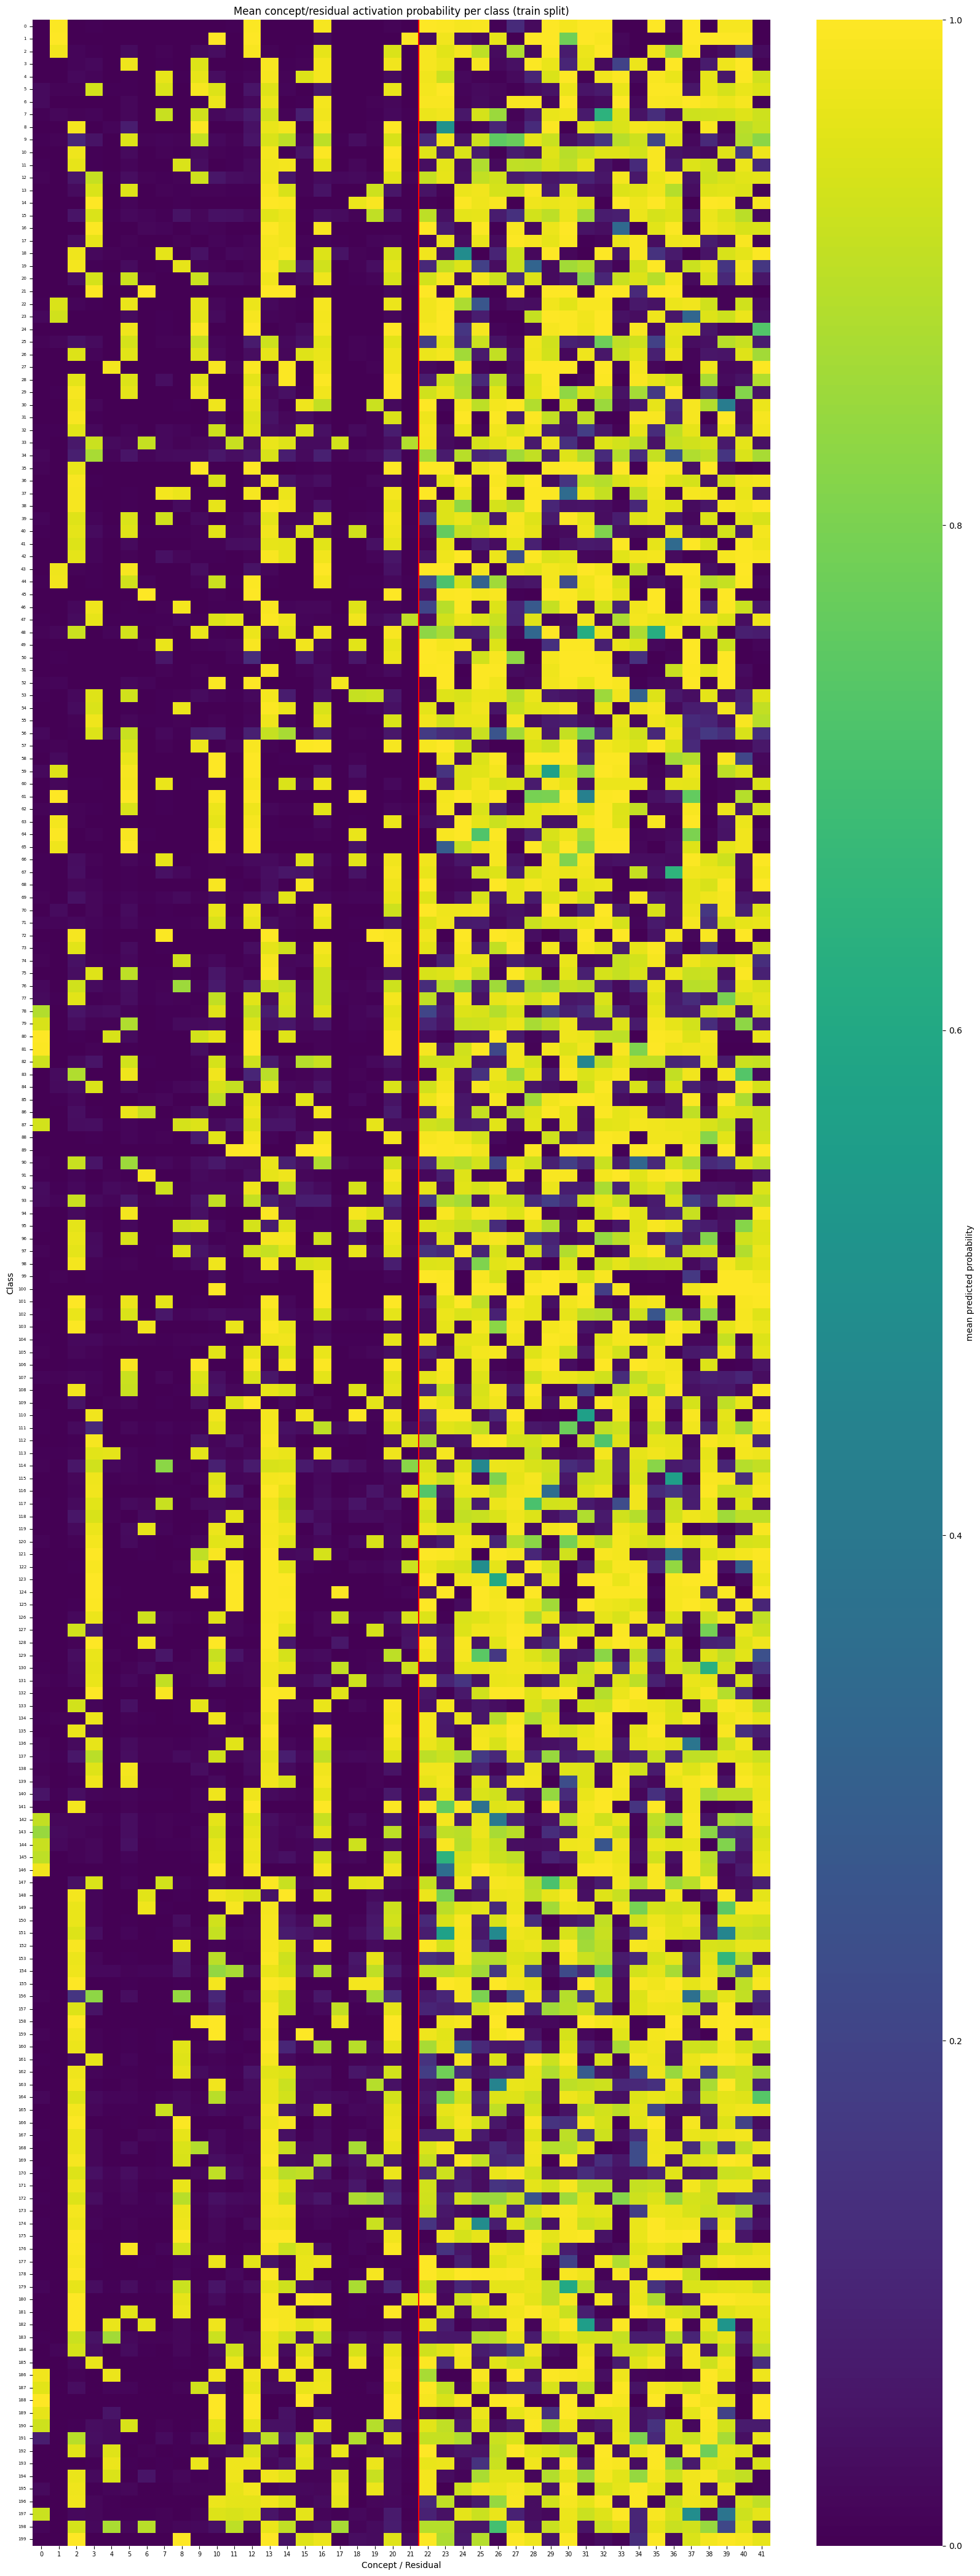

In [14]:
# Full heatmap: all 200 classes x all 22 concepts + 50 residuals
plt.figure(figsize=(16, 42))
sns.heatmap(
    class_means,
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "mean predicted probability"},
)
plt.axvline(num_concepts, color="red", linewidth=1.5)  # concepts | residuals boundary
plt.title(f"Mean concept/residual activation probability per class ({split} split)")
plt.xlabel("Concept / Residual")
plt.ylabel("Class")
plt.xticks(fontsize=7)
plt.yticks(fontsize=5)
plt.tight_layout()
plt.show()

In [15]:
# Top-k most active concepts/residuals per class (quick lookup instead of scanning the full heatmap)
def top_active_dims(class_means, k=5):
    rows = []
    for cls_name, row in class_means.iterrows():
        top = row.sort_values(ascending=False).head(k)
        rows.append({
            "class": cls_name,
            **{f"top_{i+1}": f"{name} ({val:.2f})" for i, (name, val) in enumerate(top.items())},
        })
    return pd.DataFrame(rows).set_index("class")

top_dims_df = top_active_dims(class_means, k=5)
pd.set_option("display.max_rows", None)
# display(top_dims_df)

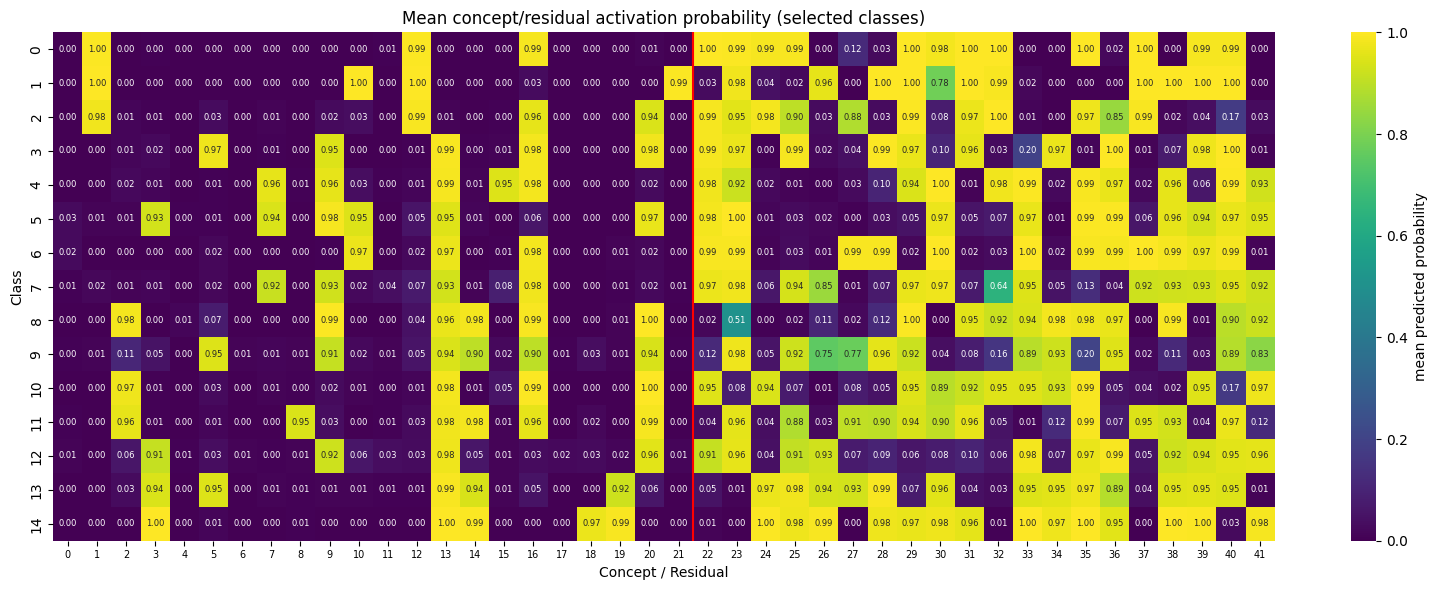

In [16]:
# Zoomed-in heatmap for a chosen subset of classes (edit CLASSES_TO_SHOW)
CLASSES_TO_SHOW = class_names[:15]  # e.g. class_names[:15], or pick specific species by name

plt.figure(figsize=(16, max(4, 0.4 * len(CLASSES_TO_SHOW))))
sns.heatmap(
    class_means.loc[CLASSES_TO_SHOW],
    cmap="viridis",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 6},
    cbar_kws={"label": "mean predicted probability"},
)
plt.axvline(num_concepts, color="red", linewidth=1.5)
plt.title("Mean concept/residual activation probability (selected classes)")
plt.xlabel("Concept / Residual")
plt.ylabel("Class")
plt.xticks(fontsize=7)
plt.tight_layout()
plt.show()

## Check that the CUB dataset is correct

In [17]:
# My code
ATTRIBUTES_IDX_USED = [1, 4, 6, 7, 10, 14, 15, 20, 21, 23, 25, 29, 30, 35, 36, 38, 40, 44, 45, 50, 51, 53, 54, 56, 57, 59, 63, 64, 69, 70, 72, 75, 80, 84, 90, 91, \
    93, 99, 101, 106, 110, 111, 116, 117, 119, 125, 126, 131, 132, 134, 145, 149, 151, 152, 153, 157, 158, 163, 164, 168, 172, 178, 179, 181, \
    183, 187, 188, 193, 194, 196, 198, 202, 203, 208, 209, 211, 212, 213, 218, 220, 221, 225, 235, 236, 238, 239, 240, 242, 243, 244, 249, 253, \
    254, 259, 260, 262, 268, 274, 277, 283, 289, 292, 293, 294, 298, 299, 304, 305, 308, 309, 310, 311]




def get_attribute_parts_to_indices():
    """
    Maps attribute idx to attribute parts (e.g. bill, wing, etc.)
    """
    
    
    # Attribute idx in the original 312 attribute space to attribute idx in the new 112 attribute space
    old_idx_to_new_idx = {old_idx: new_idx for new_idx, old_idx in enumerate(ATTRIBUTES_IDX_USED)}
    #print(old_idx_to_new_idx)
    

    path_attrubute_file = os.path.join("datasets", "CUB/CUB_200_2011/attributes.txt")



    with open(path_attrubute_file, "r") as f:
        lines = f.readlines()
        semantic_groups = {}
        for line in lines:
            idx, attr_name = line.strip().split(" ")
            idx = int(idx) - 1 # Convert to 0-based index
            if idx not in ATTRIBUTES_IDX_USED:
                continue
                
            new_idx = old_idx_to_new_idx[idx]
            semantic_group = attr_name.split("::")[0]
            if semantic_group not in semantic_groups:
                semantic_groups[semantic_group] = []
            semantic_groups[semantic_group].append(new_idx)

        return semantic_groups
    
    
print("Attribute parts to indices mapping:")
attribute_parts_to_indices = get_attribute_parts_to_indices()
for part, indices in attribute_parts_to_indices.items():
    print(f"{part}: {indices}")
    

Attribute parts to indices mapping:
has_bill_shape: [0, 1, 2, 3]
has_wing_color: [4, 5, 6, 7, 8, 9]
has_upperparts_color: [10, 11, 12, 13, 14, 15]
has_underparts_color: [16, 17, 18, 19, 20, 21]
has_breast_pattern: [22, 23, 24]
has_back_color: [25, 26, 27, 28, 29, 30]
has_tail_shape: [31]
has_upper_tail_color: [32, 33, 34, 35, 36]
has_head_pattern: [37, 38]
has_breast_color: [39, 40, 41, 42, 43, 44]
has_throat_color: [45, 46, 47, 48, 49]
has_eye_color: [50]
has_bill_length: [51, 52]
has_forehead_color: [53, 54, 55, 56, 57, 58]
has_under_tail_color: [59, 60, 61, 62, 63]
has_nape_color: [64, 65, 66, 67, 68, 69]
has_belly_color: [70, 71, 72, 73, 74, 75]
has_wing_shape: [76, 77]
has_size: [78, 79, 80]
has_shape: [81, 82]
has_back_pattern: [83, 84, 85]
has_tail_pattern: [86, 87, 88]
has_belly_pattern: [89]
has_primary_color: [90, 91, 92, 93, 94, 95]
has_leg_color: [96, 97, 98]
has_bill_color: [99, 100, 101]
has_crown_color: [102, 103, 104, 105, 106, 107]
has_wing_pattern: [108, 109, 110, 111

In [18]:
# Mateo code

from collections import defaultdict


SELECTED_CONCEPTS = [
    1,
    4,
    6,
    7,
    10,
    14,
    15,
    20,
    21,
    23,
    25,
    29,
    30,
    35,
    36,
    38,
    40,
    44,
    45,
    50,
    51,
    53,
    54,
    56,
    57,
    59,
    63,
    64,
    69,
    70,
    72,
    75,
    80,
    84,
    90,
    91,
    93,
    99,
    101,
    106,
    110,
    111,
    116,
    117,
    119,
    125,
    126,
    131,
    132,
    134,
    145,
    149,
    151,
    152,
    153,
    157,
    158,
    163,
    164,
    168,
    172,
    178,
    179,
    181,
    183,
    187,
    188,
    193,
    194,
    196,
    198,
    202,
    203,
    208,
    209,
    211,
    212,
    213,
    218,
    220,
    221,
    225,
    235,
    236,
    238,
    239,
    240,
    242,
    243,
    244,
    249,
    253,
    254,
    259,
    260,
    262,
    268,
    274,
    277,
    283,
    289,
    292,
    293,
    294,
    298,
    299,
    304,
    305,
    308,
    309,
    310,
    311,
]

# Names of all CUB attributes
CONCEPT_SEMANTICS = [
    "has_bill_shape::curved_(up_or_down)",
    "has_bill_shape::dagger",
    "has_bill_shape::hooked",
    "has_bill_shape::needle",
    "has_bill_shape::hooked_seabird",
    "has_bill_shape::spatulate",
    "has_bill_shape::all-purpose",
    "has_bill_shape::cone",
    "has_bill_shape::specialized",
    "has_wing_color::blue",
    "has_wing_color::brown",
    "has_wing_color::iridescent",
    "has_wing_color::purple",
    "has_wing_color::rufous",
    "has_wing_color::grey",
    "has_wing_color::yellow",
    "has_wing_color::olive",
    "has_wing_color::green",
    "has_wing_color::pink",
    "has_wing_color::orange",
    "has_wing_color::black",
    "has_wing_color::white",
    "has_wing_color::red",
    "has_wing_color::buff",
    "has_upperparts_color::blue",
    "has_upperparts_color::brown",
    "has_upperparts_color::iridescent",
    "has_upperparts_color::purple",
    "has_upperparts_color::rufous",
    "has_upperparts_color::grey",
    "has_upperparts_color::yellow",
    "has_upperparts_color::olive",
    "has_upperparts_color::green",
    "has_upperparts_color::pink",
    "has_upperparts_color::orange",
    "has_upperparts_color::black",
    "has_upperparts_color::white",
    "has_upperparts_color::red",
    "has_upperparts_color::buff",
    "has_underparts_color::blue",
    "has_underparts_color::brown",
    "has_underparts_color::iridescent",
    "has_underparts_color::purple",
    "has_underparts_color::rufous",
    "has_underparts_color::grey",
    "has_underparts_color::yellow",
    "has_underparts_color::olive",
    "has_underparts_color::green",
    "has_underparts_color::pink",
    "has_underparts_color::orange",
    "has_underparts_color::black",
    "has_underparts_color::white",
    "has_underparts_color::red",
    "has_underparts_color::buff",
    "has_breast_pattern::solid",
    "has_breast_pattern::spotted",
    "has_breast_pattern::striped",
    "has_breast_pattern::multi-colored",
    "has_back_color::blue",
    "has_back_color::brown",
    "has_back_color::iridescent",
    "has_back_color::purple",
    "has_back_color::rufous",
    "has_back_color::grey",
    "has_back_color::yellow",
    "has_back_color::olive",
    "has_back_color::green",
    "has_back_color::pink",
    "has_back_color::orange",
    "has_back_color::black",
    "has_back_color::white",
    "has_back_color::red",
    "has_back_color::buff",
    "has_tail_shape::forked_tail",
    "has_tail_shape::rounded_tail",
    "has_tail_shape::notched_tail",
    "has_tail_shape::fan-shaped_tail",
    "has_tail_shape::pointed_tail",
    "has_tail_shape::squared_tail",
    "has_upper_tail_color::blue",
    "has_upper_tail_color::brown",
    "has_upper_tail_color::iridescent",
    "has_upper_tail_color::purple",
    "has_upper_tail_color::rufous",
    "has_upper_tail_color::grey",
    "has_upper_tail_color::yellow",
    "has_upper_tail_color::olive",
    "has_upper_tail_color::green",
    "has_upper_tail_color::pink",
    "has_upper_tail_color::orange",
    "has_upper_tail_color::black",
    "has_upper_tail_color::white",
    "has_upper_tail_color::red",
    "has_upper_tail_color::buff",
    "has_head_pattern::spotted",
    "has_head_pattern::malar",
    "has_head_pattern::crested",
    "has_head_pattern::masked",
    "has_head_pattern::unique_pattern",
    "has_head_pattern::eyebrow",
    "has_head_pattern::eyering",
    "has_head_pattern::plain",
    "has_head_pattern::eyeline",
    "has_head_pattern::striped",
    "has_head_pattern::capped",
    "has_breast_color::blue",
    "has_breast_color::brown",
    "has_breast_color::iridescent",
    "has_breast_color::purple",
    "has_breast_color::rufous",
    "has_breast_color::grey",
    "has_breast_color::yellow",
    "has_breast_color::olive",
    "has_breast_color::green",
    "has_breast_color::pink",
    "has_breast_color::orange",
    "has_breast_color::black",
    "has_breast_color::white",
    "has_breast_color::red",
    "has_breast_color::buff",
    "has_throat_color::blue",
    "has_throat_color::brown",
    "has_throat_color::iridescent",
    "has_throat_color::purple",
    "has_throat_color::rufous",
    "has_throat_color::grey",
    "has_throat_color::yellow",
    "has_throat_color::olive",
    "has_throat_color::green",
    "has_throat_color::pink",
    "has_throat_color::orange",
    "has_throat_color::black",
    "has_throat_color::white",
    "has_throat_color::red",
    "has_throat_color::buff",
    "has_eye_color::blue",
    "has_eye_color::brown",
    "has_eye_color::purple",
    "has_eye_color::rufous",
    "has_eye_color::grey",
    "has_eye_color::yellow",
    "has_eye_color::olive",
    "has_eye_color::green",
    "has_eye_color::pink",
    "has_eye_color::orange",
    "has_eye_color::black",
    "has_eye_color::white",
    "has_eye_color::red",
    "has_eye_color::buff",
    "has_bill_length::about_the_same_as_head",
    "has_bill_length::longer_than_head",
    "has_bill_length::shorter_than_head",
    "has_forehead_color::blue",
    "has_forehead_color::brown",
    "has_forehead_color::iridescent",
    "has_forehead_color::purple",
    "has_forehead_color::rufous",
    "has_forehead_color::grey",
    "has_forehead_color::yellow",
    "has_forehead_color::olive",
    "has_forehead_color::green",
    "has_forehead_color::pink",
    "has_forehead_color::orange",
    "has_forehead_color::black",
    "has_forehead_color::white",
    "has_forehead_color::red",
    "has_forehead_color::buff",
    "has_under_tail_color::blue",
    "has_under_tail_color::brown",
    "has_under_tail_color::iridescent",
    "has_under_tail_color::purple",
    "has_under_tail_color::rufous",
    "has_under_tail_color::grey",
    "has_under_tail_color::yellow",
    "has_under_tail_color::olive",
    "has_under_tail_color::green",
    "has_under_tail_color::pink",
    "has_under_tail_color::orange",
    "has_under_tail_color::black",
    "has_under_tail_color::white",
    "has_under_tail_color::red",
    "has_under_tail_color::buff",
    "has_nape_color::blue",
    "has_nape_color::brown",
    "has_nape_color::iridescent",
    "has_nape_color::purple",
    "has_nape_color::rufous",
    "has_nape_color::grey",
    "has_nape_color::yellow",
    "has_nape_color::olive",
    "has_nape_color::green",
    "has_nape_color::pink",
    "has_nape_color::orange",
    "has_nape_color::black",
    "has_nape_color::white",
    "has_nape_color::red",
    "has_nape_color::buff",
    "has_belly_color::blue",
    "has_belly_color::brown",
    "has_belly_color::iridescent",
    "has_belly_color::purple",
    "has_belly_color::rufous",
    "has_belly_color::grey",
    "has_belly_color::yellow",
    "has_belly_color::olive",
    "has_belly_color::green",
    "has_belly_color::pink",
    "has_belly_color::orange",
    "has_belly_color::black",
    "has_belly_color::white",
    "has_belly_color::red",
    "has_belly_color::buff",
    "has_wing_shape::rounded-wings",
    "has_wing_shape::pointed-wings",
    "has_wing_shape::broad-wings",
    "has_wing_shape::tapered-wings",
    "has_wing_shape::long-wings",
    "has_size::large_(16_-_32_in)",
    "has_size::small_(5_-_9_in)",
    "has_size::very_large_(32_-_72_in)",
    "has_size::medium_(9_-_16_in)",
    "has_size::very_small_(3_-_5_in)",
    "has_shape::upright-perching_water-like",
    "has_shape::chicken-like-marsh",
    "has_shape::long-legged-like",
    "has_shape::duck-like",
    "has_shape::owl-like",
    "has_shape::gull-like",
    "has_shape::hummingbird-like",
    "has_shape::pigeon-like",
    "has_shape::tree-clinging-like",
    "has_shape::hawk-like",
    "has_shape::sandpiper-like",
    "has_shape::upland-ground-like",
    "has_shape::swallow-like",
    "has_shape::perching-like",
    "has_back_pattern::solid",
    "has_back_pattern::spotted",
    "has_back_pattern::striped",
    "has_back_pattern::multi-colored",
    "has_tail_pattern::solid",
    "has_tail_pattern::spotted",
    "has_tail_pattern::striped",
    "has_tail_pattern::multi-colored",
    "has_belly_pattern::solid",
    "has_belly_pattern::spotted",
    "has_belly_pattern::striped",
    "has_belly_pattern::multi-colored",
    "has_primary_color::blue",
    "has_primary_color::brown",
    "has_primary_color::iridescent",
    "has_primary_color::purple",
    "has_primary_color::rufous",
    "has_primary_color::grey",
    "has_primary_color::yellow",
    "has_primary_color::olive",
    "has_primary_color::green",
    "has_primary_color::pink",
    "has_primary_color::orange",
    "has_primary_color::black",
    "has_primary_color::white",
    "has_primary_color::red",
    "has_primary_color::buff",
    "has_leg_color::blue",
    "has_leg_color::brown",
    "has_leg_color::iridescent",
    "has_leg_color::purple",
    "has_leg_color::rufous",
    "has_leg_color::grey",
    "has_leg_color::yellow",
    "has_leg_color::olive",
    "has_leg_color::green",
    "has_leg_color::pink",
    "has_leg_color::orange",
    "has_leg_color::black",
    "has_leg_color::white",
    "has_leg_color::red",
    "has_leg_color::buff",
    "has_bill_color::blue",
    "has_bill_color::brown",
    "has_bill_color::iridescent",
    "has_bill_color::purple",
    "has_bill_color::rufous",
    "has_bill_color::grey",
    "has_bill_color::yellow",
    "has_bill_color::olive",
    "has_bill_color::green",
    "has_bill_color::pink",
    "has_bill_color::orange",
    "has_bill_color::black",
    "has_bill_color::white",
    "has_bill_color::red",
    "has_bill_color::buff",
    "has_crown_color::blue",
    "has_crown_color::brown",
    "has_crown_color::iridescent",
    "has_crown_color::purple",
    "has_crown_color::rufous",
    "has_crown_color::grey",
    "has_crown_color::yellow",
    "has_crown_color::olive",
    "has_crown_color::green",
    "has_crown_color::pink",
    "has_crown_color::orange",
    "has_crown_color::black",
    "has_crown_color::white",
    "has_crown_color::red",
    "has_crown_color::buff",
    "has_wing_pattern::solid",
    "has_wing_pattern::spotted",
    "has_wing_pattern::striped",
    "has_wing_pattern::multi-colored",
]

# Generate a mapping containing all concept groups in CUB generated
# using a simple prefix tree
CONCEPT_GROUP_MAP = defaultdict(list)
for i, concept_name in enumerate(list(
    np.array(CONCEPT_SEMANTICS)[SELECTED_CONCEPTS]
)):
    group = concept_name[:concept_name.find("::")]
    CONCEPT_GROUP_MAP[group].append(i)

print("Concept groups and their indices:")
for group, indices in CONCEPT_GROUP_MAP.items():
    print(f"  {group}: {indices}")

Concept groups and their indices:
  has_bill_shape: [0, 1, 2, 3]
  has_wing_color: [4, 5, 6, 7, 8, 9]
  has_upperparts_color: [10, 11, 12, 13, 14, 15]
  has_underparts_color: [16, 17, 18, 19, 20, 21]
  has_breast_pattern: [22, 23, 24]
  has_back_color: [25, 26, 27, 28, 29, 30]
  has_tail_shape: [31]
  has_upper_tail_color: [32, 33, 34, 35, 36]
  has_head_pattern: [37, 38]
  has_breast_color: [39, 40, 41, 42, 43, 44]
  has_throat_color: [45, 46, 47, 48, 49]
  has_eye_color: [50]
  has_bill_length: [51, 52]
  has_forehead_color: [53, 54, 55, 56, 57, 58]
  has_under_tail_color: [59, 60, 61, 62, 63]
  has_nape_color: [64, 65, 66, 67, 68, 69]
  has_belly_color: [70, 71, 72, 73, 74, 75]
  has_wing_shape: [76, 77]
  has_size: [78, 79, 80]
  has_shape: [81, 82]
  has_back_pattern: [83, 84, 85]
  has_tail_pattern: [86, 87, 88]
  has_belly_pattern: [89]
  has_primary_color: [90, 91, 92, 93, 94, 95]
  has_leg_color: [96, 97, 98]
  has_bill_color: [99, 100, 101]
  has_crown_color: [102, 103, 104, 

In [19]:
# Check if the two dictionaries are consistent
for group, indices in CONCEPT_GROUP_MAP.items():
    indices_second = attribute_parts_to_indices.get(group, [])
    if set(indices) != set(indices_second):
        print(f"Mismatch in group '{group}':")
        print(f"  CONCEPT_GROUP_MAP indices: {indices}")
        print(f"  attribute_parts_to_indices indices: {indices_second}")

## Check that the samples we have data for is in same order as data generated

As they match we know the order of the samples from the model, thus we know the hidden residuals for each sample

In [20]:
splits = ["train", "val", "test"]

for split in splits:
    y_true_from_model = torch.load(os.path.join(EXPERIMENT_PATH, split, "y_true.pt"))
    
    train_data_path = os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", f"{split}.pkl")
    
    # Load the train data
    train_data = pd.read_pickle(train_data_path)
    y_true_from_dataset = []
    for sample in train_data:
        y_true_from_dataset.append(sample["class_label"])
    y_true_from_dataset = torch.tensor(y_true_from_dataset)
    
    # Check if the two y_true tensors are equal
    if torch.equal(y_true_from_model, y_true_from_dataset):
        print(f"y_true tensors match for split '{split}'")
    else:
        print(f"y_true tensors do NOT match for split '{split}'")
    
    
    
    

y_true tensors match for split 'train'
y_true tensors match for split 'val'
y_true tensors match for split 'test'


## Plot train/test/val ground truth distribution

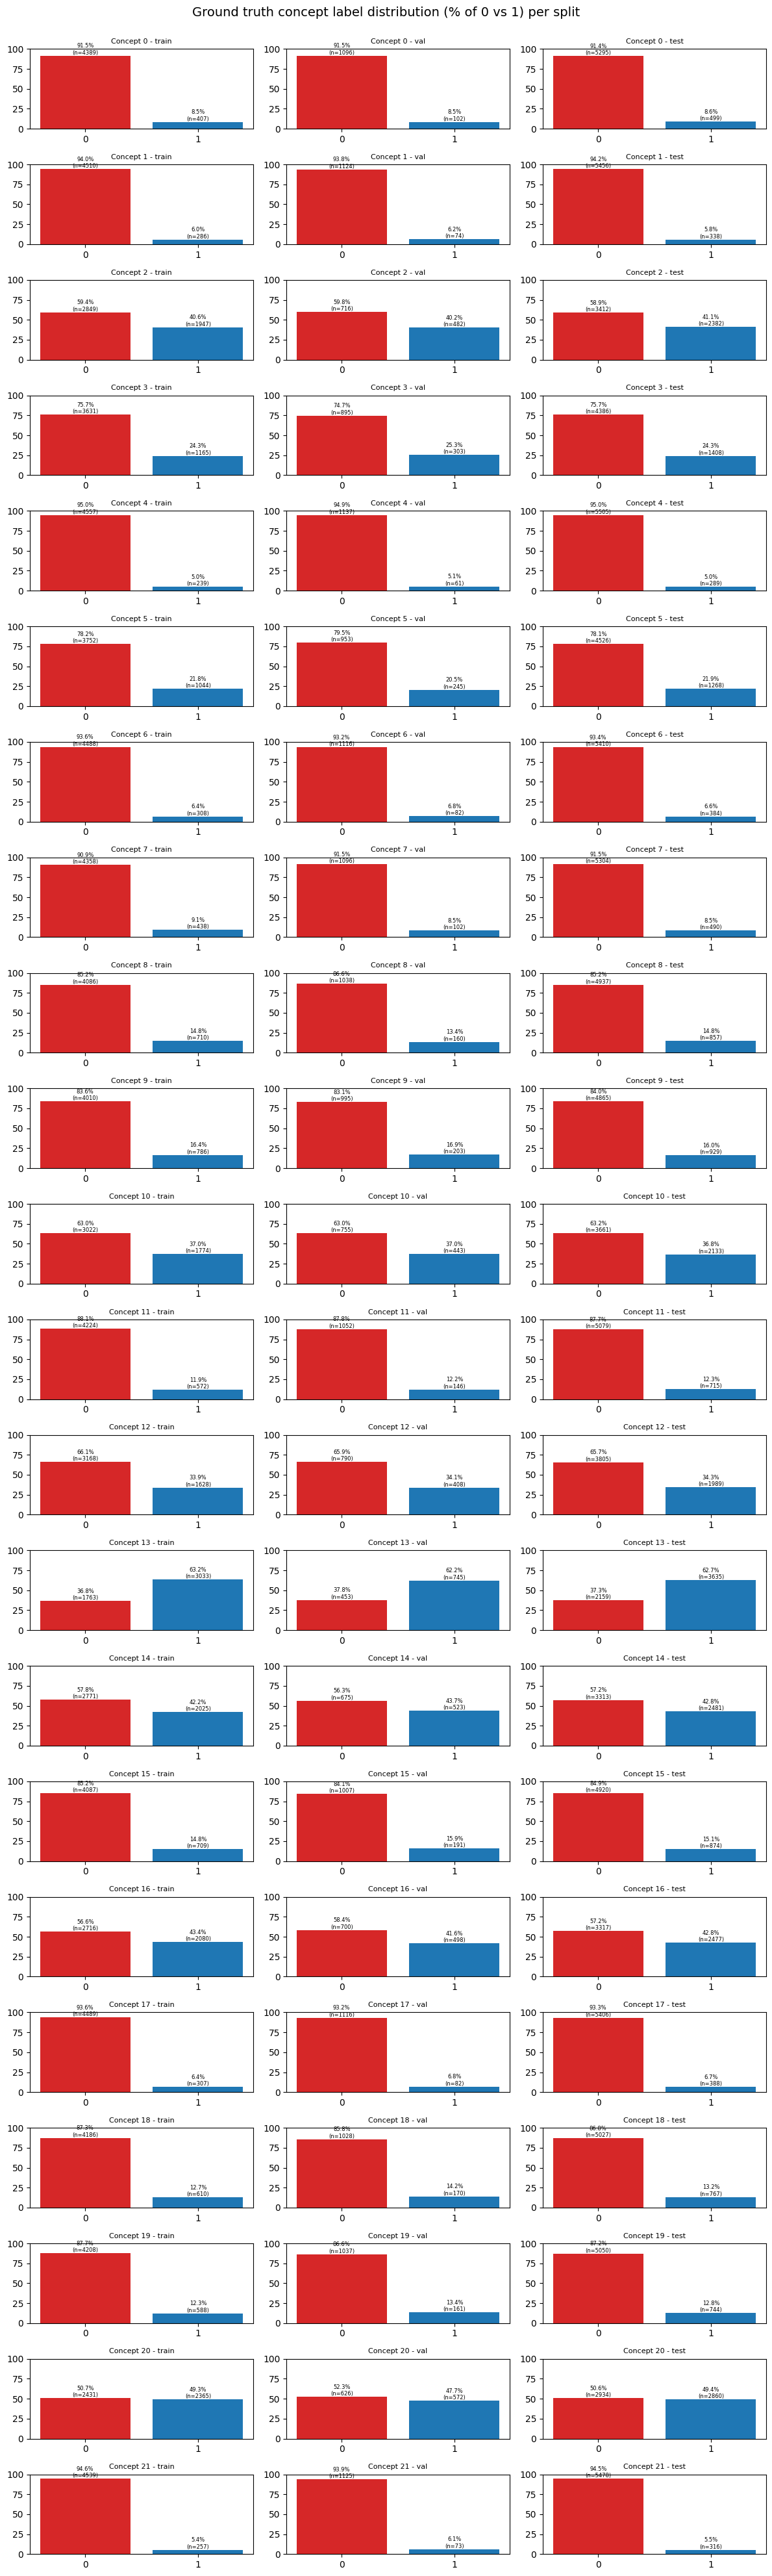

In [ ]:
GT_NUM_CONCEPTS = 22
gt_splits = ["train", "val", "test"]

gt_concepts_by_split = {}
for split in gt_splits:
    data_pkl = pd.read_pickle(os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", f"{split}.pkl"))
    gt_concepts_by_split[split] = np.array([sample["attribute_label"] for sample in data_pkl])

fig, axes = plt.subplots(
    GT_NUM_CONCEPTS, len(gt_splits),
    figsize=(4 * len(gt_splits), 1.8 * GT_NUM_CONCEPTS),
)

for row in range(GT_NUM_CONCEPTS):
    for col, split in enumerate(gt_splits):
        ax = axes[row, col]
        c_true = gt_concepts_by_split[split][:, row]
        n = len(c_true)
        num_ones = int(c_true.sum())
        num_zeros = n - num_ones
        pct_zeros = 100 * num_zeros / n
        pct_ones = 100 * num_ones / n
        ax.bar(["0", "1"], [pct_zeros, pct_ones], color=["tab:red", "tab:blue"])
        ax.set_ylim(0, 100)
        ax.set_title(f"Concept {row} - {split}", fontsize=8)
        for x, (pct, count) in enumerate([(pct_zeros, num_zeros), (pct_ones, num_ones)]):
            ax.text(x, pct, f"{pct:.1f}%\n(n={count})", ha="center", va="bottom", fontsize=6)

fig.suptitle("Ground truth concept label distribution (% of 0 vs 1) per split", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

## Train vs test logit distribution comparison

`train` logits are computed from images passed through the training-time augmentation
transform (`ColorJitter`, `RandomResizedCrop`, `RandomHorizontalFlip`), while `val`/`test`
use a deterministic `CenterCrop`. To check whether the train-vs-test logit shrinkage
above is a genuine train/test generalization gap or an artifact of comparing augmented
vs. deterministic inputs, `inference.py` was extended to also dump `train_with_test_transform`: the
same train images, passed through the deterministic test-time transform instead of the
training augmentation (see `datasets/CUB_dataset.py::get_CUB_transforms` and
`inference.py`'s `train_clean_analysis_loader`). This isolates the confound: `train_clean`
vs `test` is now an apples-to-apples "clean image, seen during training vs. clean image,
held out" comparison.

In [21]:

NUM_CONCEPTS_CLEAN = 22

train_aug_logits = torch.load(os.path.join(EXPERIMENT_PATH, "train", "concepts_residuals_logits_mean.pt"))
train_clean_logits = torch.load(os.path.join(EXPERIMENT_PATH, "train_with_test_transform", "concepts_residuals_logits_mean.pt"))
test_clean_logits = torch.load(os.path.join(EXPERIMENT_PATH, "test", "concepts_residuals_logits_mean.pt"))

print("train (augmented):", train_aug_logits.shape, "mean", train_aug_logits.mean().item(), "std", train_aug_logits.std().item())
print("train_clean (deterministic):", train_clean_logits.shape, "mean", train_clean_logits.mean().item(), "std", train_clean_logits.std().item())
print("test (deterministic):", test_clean_logits.shape, "mean", test_clean_logits.mean().item(), "std", test_clean_logits.std().item())

num_dims_clean = train_aug_logits.shape[1]


train (augmented): torch.Size([4796, 42]) mean -3.2621009349823 std 12.402484893798828
train_clean (deterministic): torch.Size([4796, 42]) mean -3.661890745162964 std 13.846214294433594
test (deterministic): torch.Size([5794, 42]) mean -2.62231707572937 std 8.852278709411621


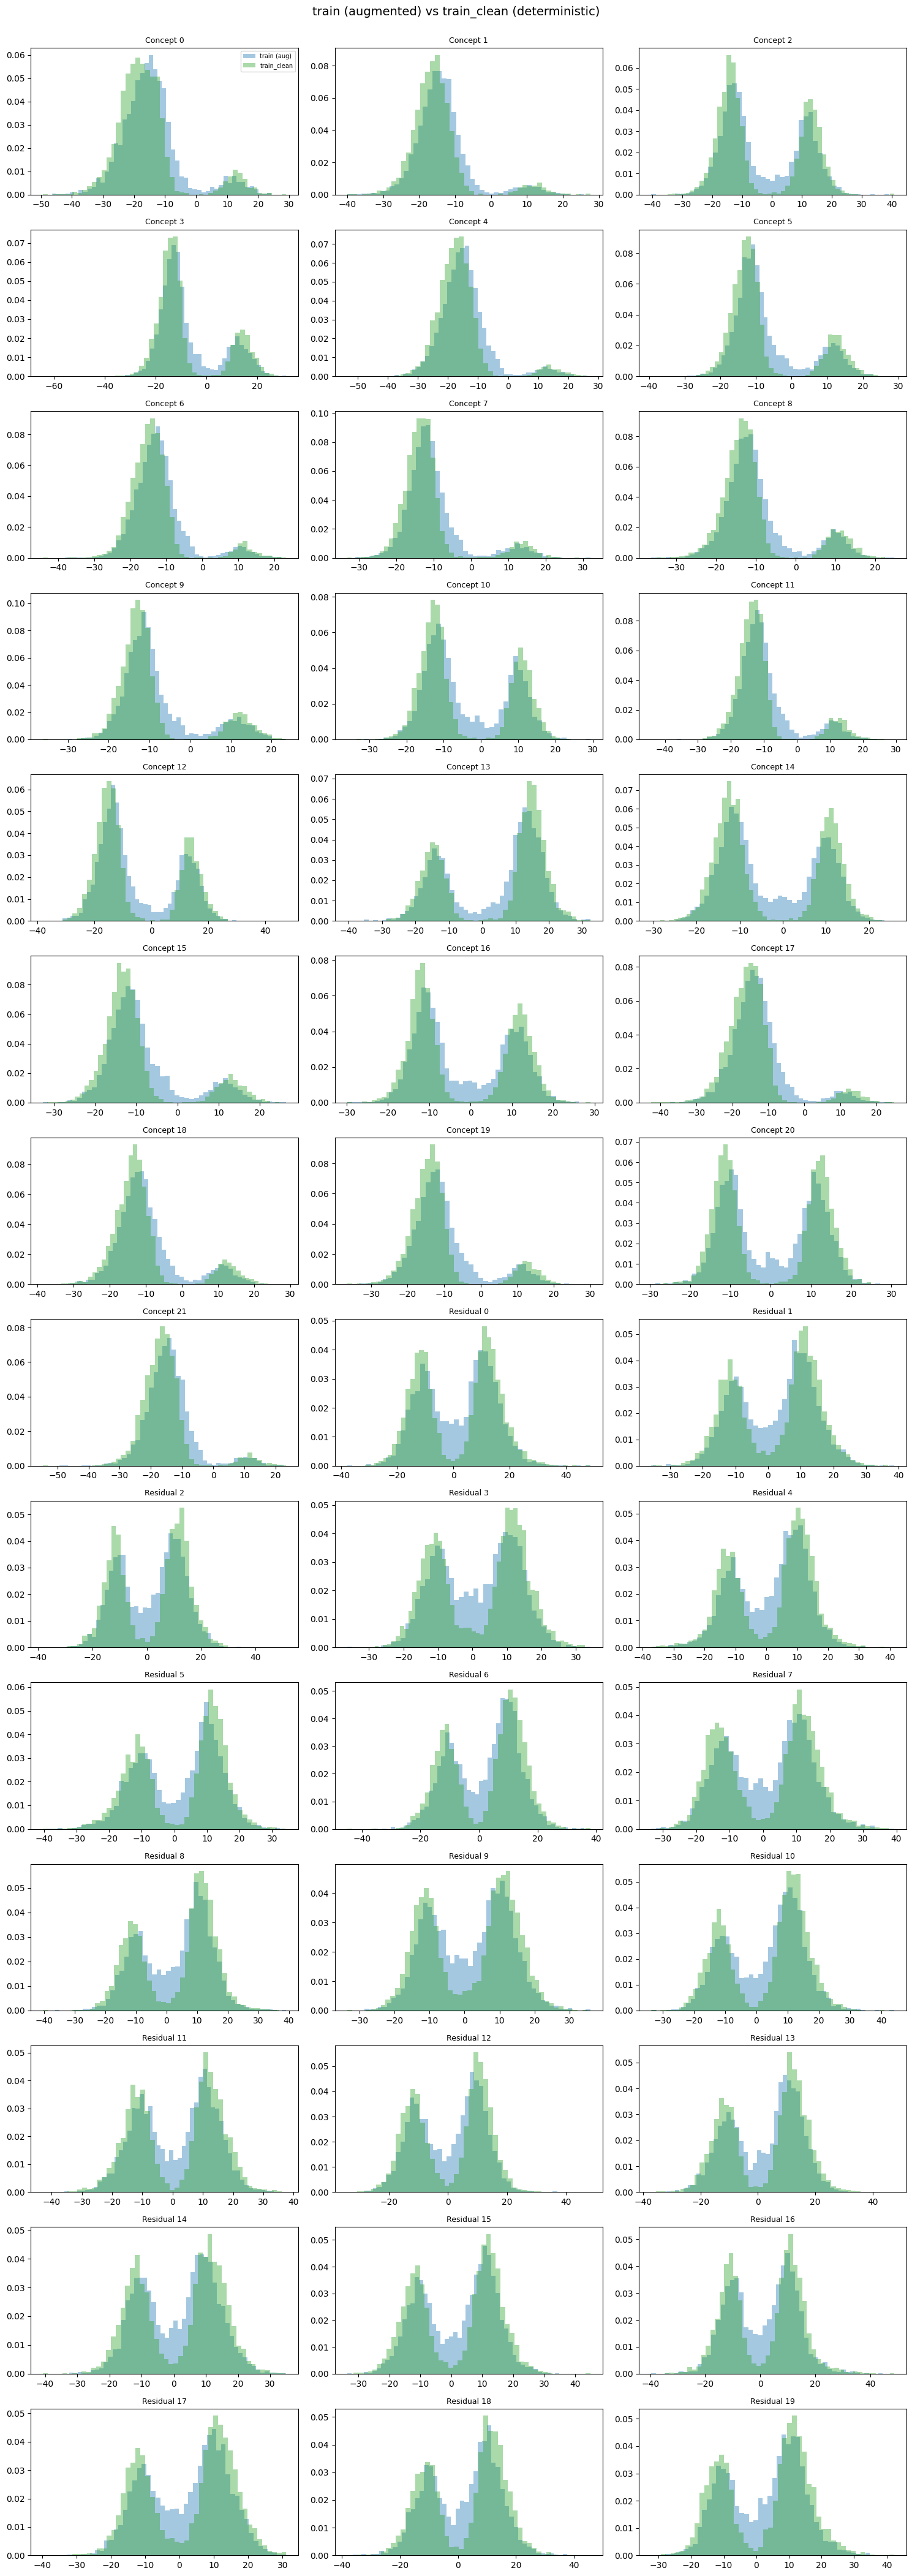

In [22]:
# Overlaid histograms: train (augmented) vs train_clean (deterministic) vs test, per dimension
num_cols = 3
num_rows = math.ceil(num_dims_clean / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(num_dims_clean):
    ax = axes[i]
    is_concept = i < NUM_CONCEPTS_CLEAN
    label = f"Concept {i}" if is_concept else f"Residual {i - NUM_CONCEPTS_CLEAN}"
    ax.hist(train_aug_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train (aug)", color="tab:blue")
    ax.hist(train_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train_clean", color="tab:green")
    ax.set_title(label, fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

for ax in axes[num_dims_clean:]:
    ax.axis("off")

fig.suptitle("train (augmented) vs train_clean (deterministic)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

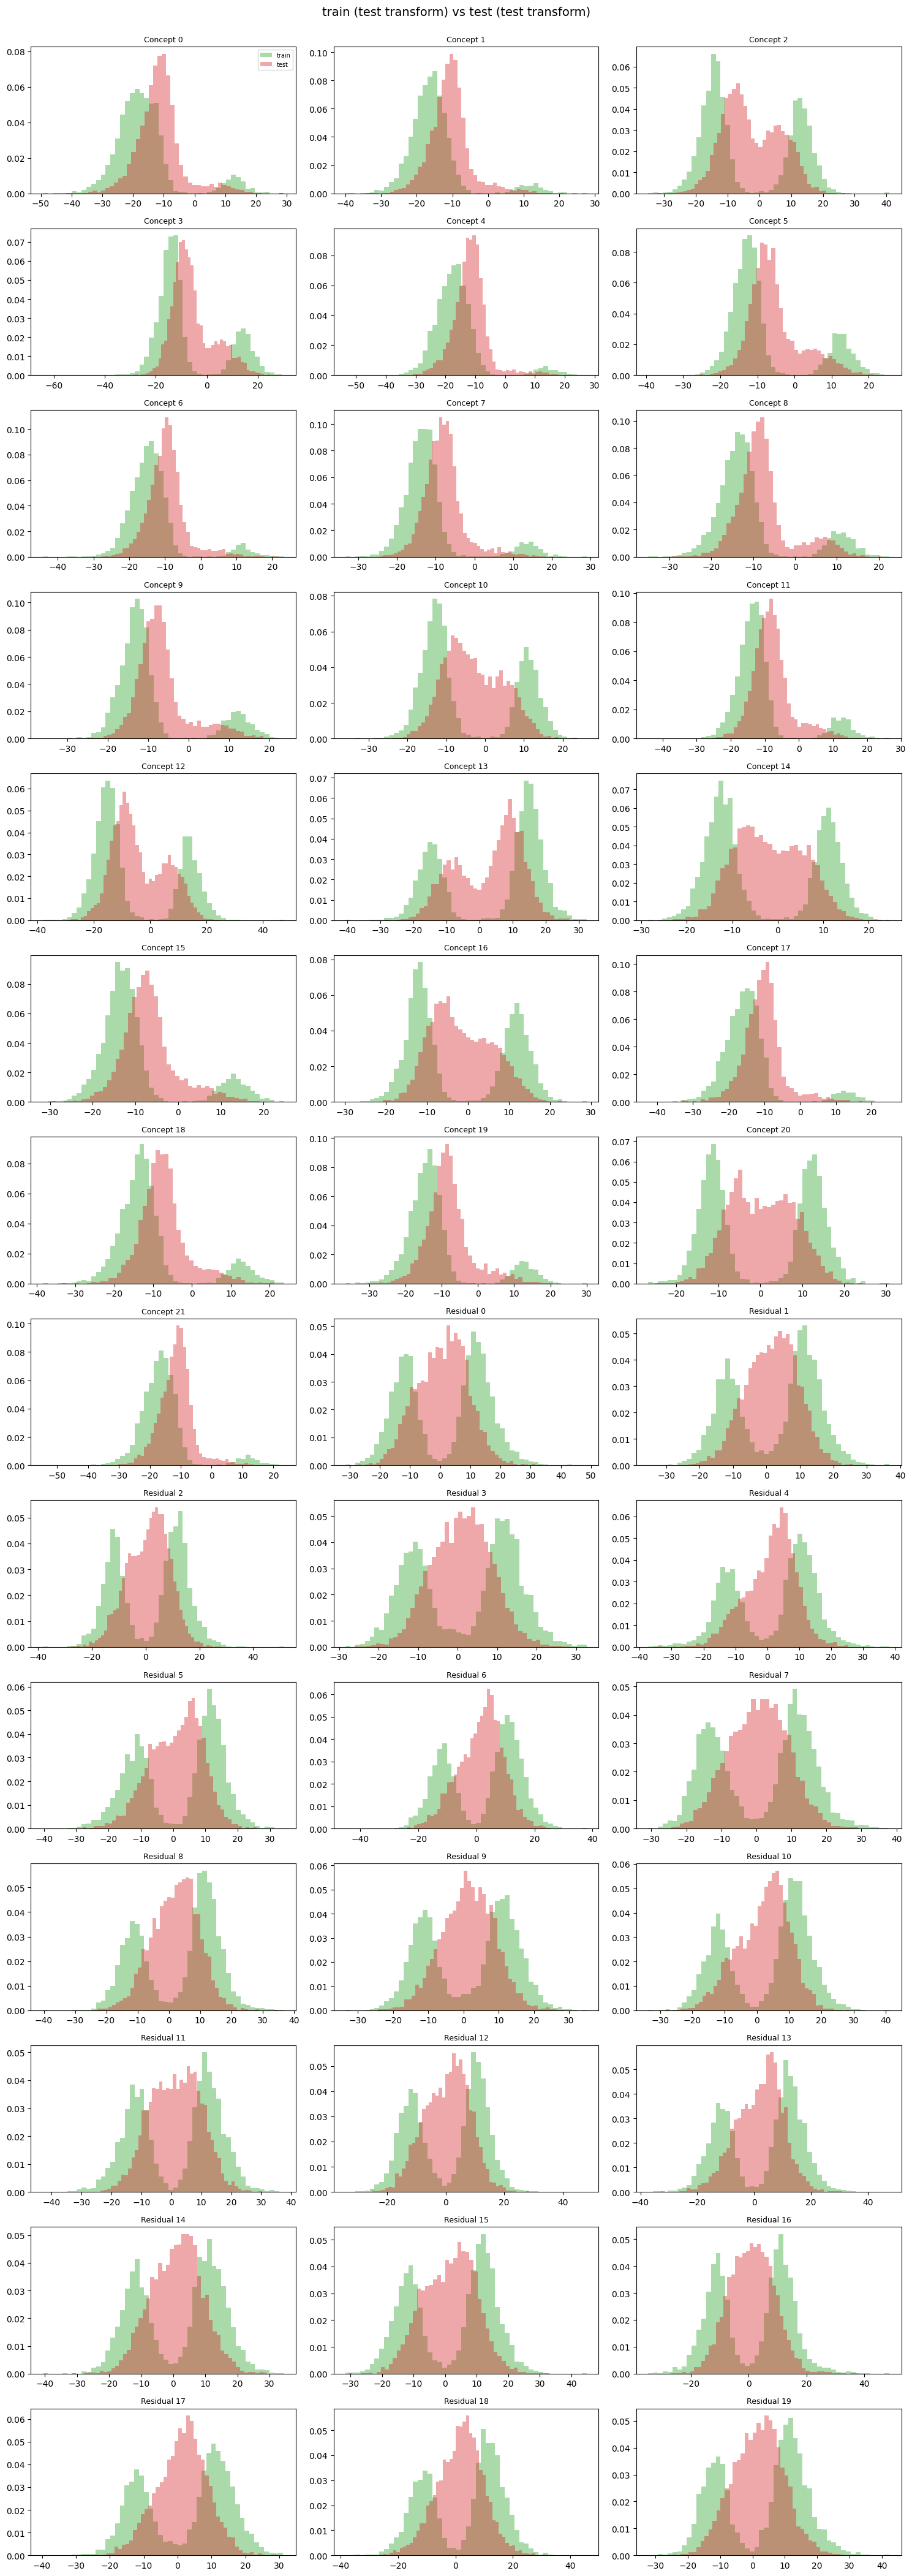

In [30]:
# Overlaid histograms: train (augmented) vs train_clean (deterministic) vs test, per dimension
num_cols = 3
num_rows = math.ceil(num_dims_clean / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(num_dims_clean):
    ax = axes[i]
    is_concept = i < NUM_CONCEPTS_CLEAN
    label = f"Concept {i}" if is_concept else f"Residual {i - NUM_CONCEPTS_CLEAN}"
    ax.hist(train_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train", color="tab:green")
    ax.hist(test_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="test", color="tab:red")
    ax.set_title(label, fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

for ax in axes[num_dims_clean:]:
    ax.axis("off")

fig.suptitle("train (test transform) vs test (test transform)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

## Concept accuracy and AUROC across splits (including train_clean)

Reproduces `c_accuracy` / `complete_c_accuracy` (`utils/training.py`'s `Custom_Metrics.compute`) and macro-averaged per-concept `c_AUROC` (`utils/metrics.py`'s `calc_concept_metrics`) directly from the saved `concepts_residuals_pred_probs_mean.pt` artifacts, using concept ground truth (`attribute_label`) read from the same pkl files used for the `y_true` order check above. `train_with_test_transform` reuses the train split's pkl (same underlying images, just the deterministic transform instead of augmentation) and uses the same `EXPERIMENT_PATH` as the section above.

In [24]:
from sklearn.metrics import roc_auc_score

CONCEPT_METRICS_NUM_CONCEPTS = 22

splits_to_check = {
    "train": "train",
    "train_with_test_transform": "train",  # same underlying images as train, deterministic transform
    "val": "val",
    "test": "test",
}

concept_metrics_rows = []
for folder_name, pkl_split in splits_to_check.items():
    data_pkl = pd.read_pickle(os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", f"{pkl_split}.pkl"))
    c_true = np.array([sample["attribute_label"] for sample in data_pkl])

    c_r_probs_split = torch.load(os.path.join(EXPERIMENT_PATH, folder_name, "concepts_residuals_pred_probs_mean.pt"))
    c_pred_probs = c_r_probs_split[:, :CONCEPT_METRICS_NUM_CONCEPTS].numpy()
    c_pred = c_pred_probs > 0.5

    c_accuracy = (c_true == c_pred).mean()
    complete_c_accuracy = (c_true == c_pred).all(axis=1).mean()
    per_concept_auroc = [roc_auc_score(c_true[:, j], c_pred_probs[:, j]) for j in range(CONCEPT_METRICS_NUM_CONCEPTS)]
    c_auroc = float(np.mean(per_concept_auroc))

    concept_metrics_rows.append({
        "split": folder_name,
        "n_samples": c_true.shape[0],
        "c_accuracy": c_accuracy,
        "complete_c_accuracy": complete_c_accuracy,
        "c_AUROC": c_auroc,
    })

concept_metrics_df = pd.DataFrame(concept_metrics_rows).set_index("split")
display(concept_metrics_df)

,n_samples,c_accuracy,complete_c_accuracy,c_AUROC
split,,,,
train,4796,0.989508,0.914721,0.999139
train_with_test_transform,4796,0.999460,0.994996,0.999995
val,1198,0.947109,0.564274,0.972909
test,5794,0.948646,0.568519,0.975867


## AUC heatmap

In [25]:
full_dataset_path = os.path.join("datasets", "CUB", "class_attr_data_10")



Top 5 missing concepts and their indices:
  has_breast_pattern::striped: 23
  has_size::very_small_(3_-_5_in): 80
  has_shape::duck-like: 81
  has_primary_color::yellow: 92
  has_wing_pattern::striped: 110


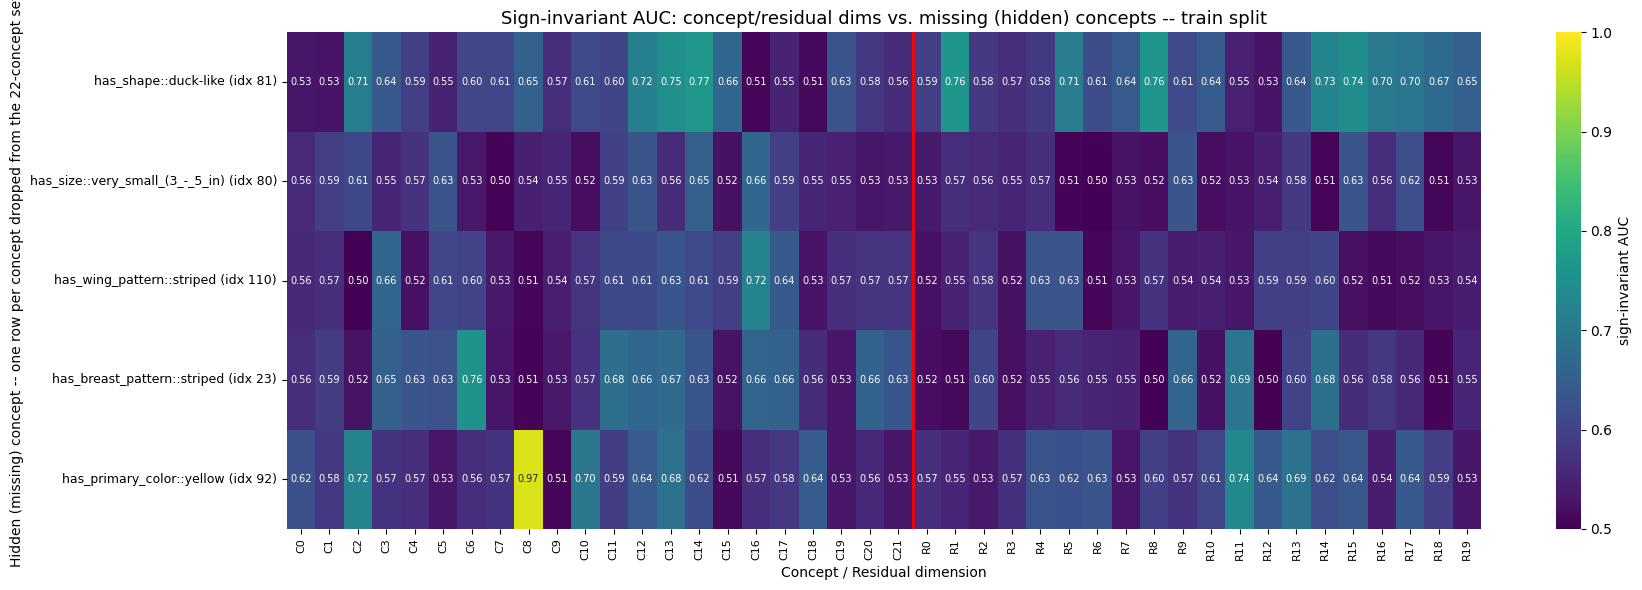

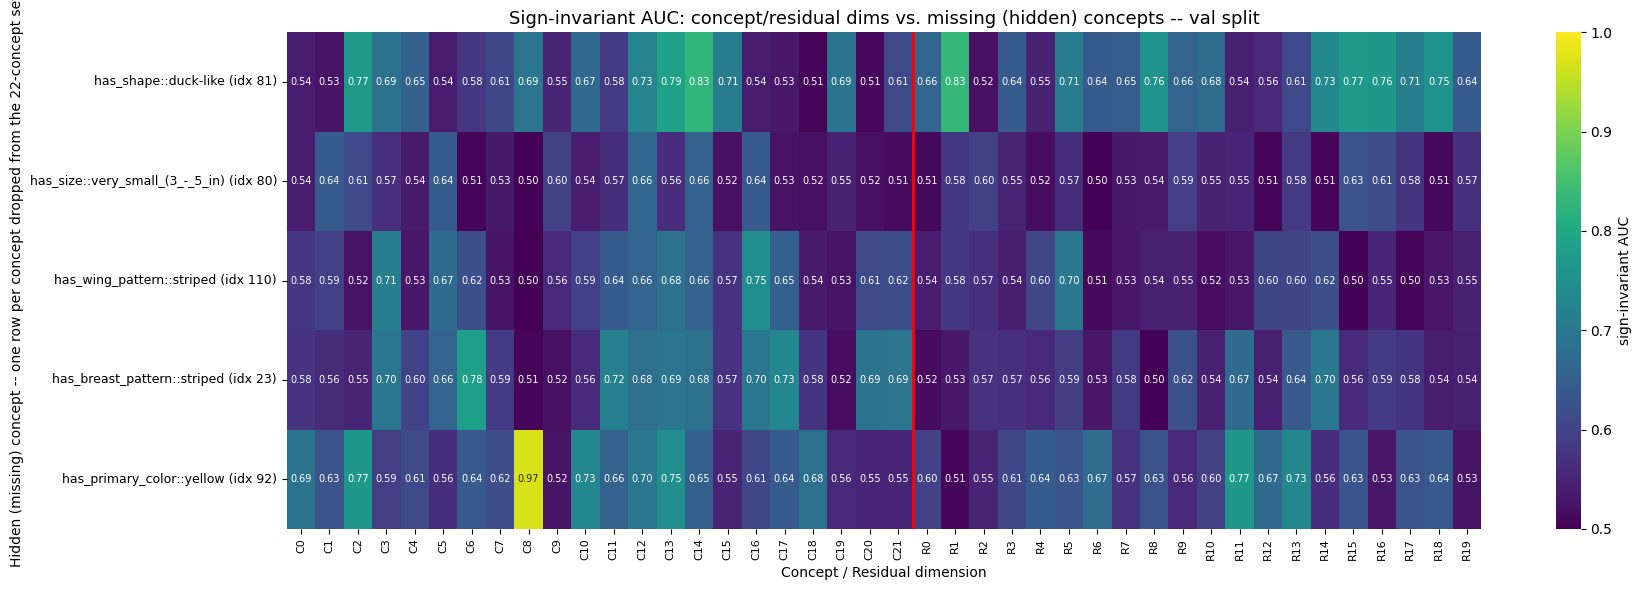

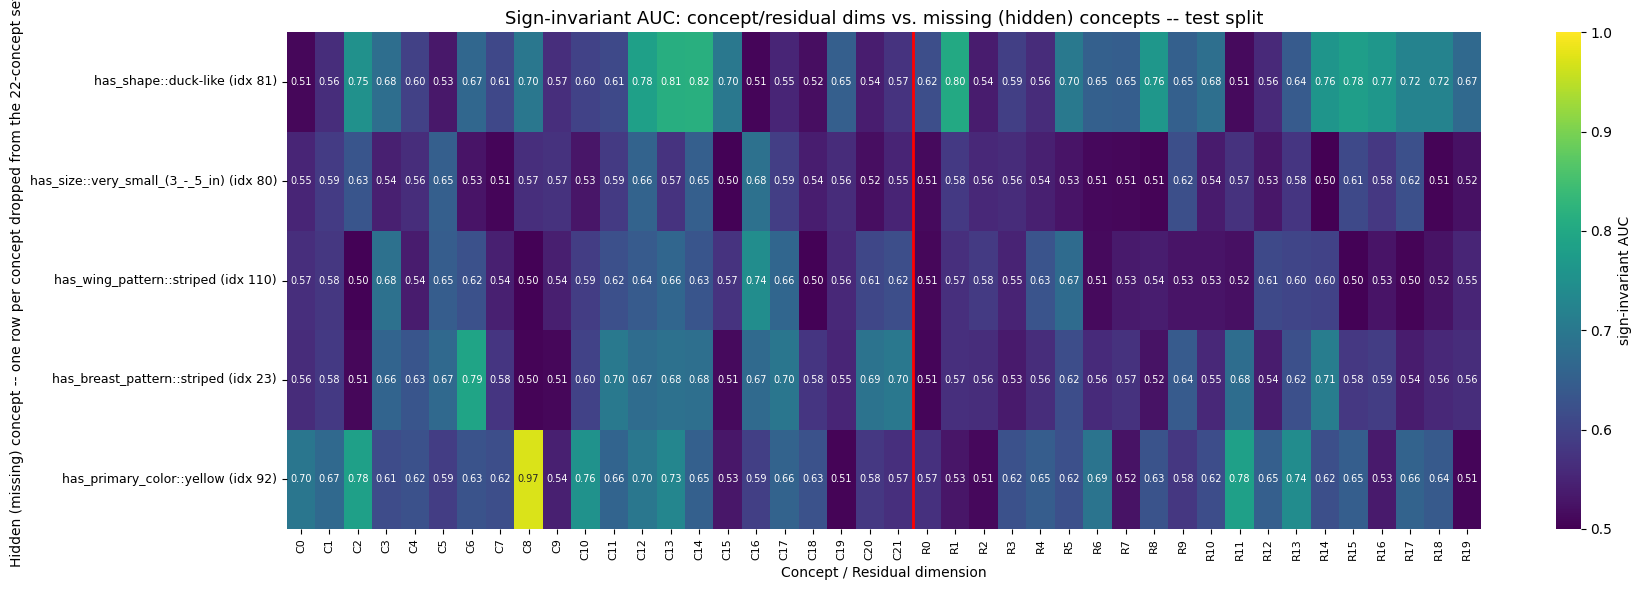

In [26]:
top5_missing_concepts = [
    "has_shape::duck-like",
    "has_size::very_small_(3_-_5_in)",
    "has_wing_pattern::striped",
    "has_breast_pattern::striped",
    "has_primary_color::yellow",
]

idx_top5_missing_concepts = {}


for key, val in sample_112_concepts_map.items():

    if val in top5_missing_concepts:
        idx_top5_missing_concepts[val] = key

print("Top 5 missing concepts and their indices:")
for concept, idx in idx_top5_missing_concepts.items():
    print(f"  {concept}: {idx}")



# Plot AUC Heat map of top 5 missing concepts and residuals for each split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Full (112-concept) dataset: same samples/order as the 22-concept "incomplete" pkls
# (verified ids match exactly), but attribute_label here is indexed 0-111, i.e. directly
# by the same index as idx_top5_missing_concepts -- no need to go through the original
# 312-attribute space.
full_dataset_path = os.path.join("datasets", "CUB", "class_attr_data_10")

heatmap_num_concepts = 22
heatmap_splits = ["train", "val", "test"]

# y-axis: one row per missing (hidden) concept -- row order matches top5_missing_concepts.
# Label each row with the concept name plus its index in the 112-concept space, so it's
# unambiguous which row is which hidden concept.
y_axis_labels = [f"{concept} (idx {idx_top5_missing_concepts[concept]})" for concept in top5_missing_concepts]

for split in heatmap_splits:
    full_split_data = pd.read_pickle(os.path.join(full_dataset_path, f"{split}.pkl"))

    c_r_probs_split = torch.load(
        os.path.join(EXPERIMENT_PATH, split, "concepts_residuals_pred_probs_mean.pt")
    ).numpy()
    num_dims = c_r_probs_split.shape[1]
    dim_labels = [f"C{i}" if i < heatmap_num_concepts else f"R{i - heatmap_num_concepts}" for i in range(num_dims)]

    auc_matrix = np.full((len(top5_missing_concepts), num_dims), np.nan)
    for row, concept in enumerate(top5_missing_concepts):
        concept_idx_112 = idx_top5_missing_concepts[concept]
        c_true_missing = np.array([sample["attribute_label"][concept_idx_112] for sample in full_split_data])

        if len(np.unique(c_true_missing)) < 2:
            continue  # concept has no variation in this split, AUC undefined

        for col in range(num_dims):
            raw_auc = roc_auc_score(c_true_missing, c_r_probs_split[:, col])
            auc_matrix[row, col] = max(raw_auc, 1 - raw_auc)  # sign-invariant AUC

    fig, ax = plt.subplots(figsize=(18, 6))
    sns.heatmap(
        auc_matrix,
        ax=ax,
        cmap="viridis",
        vmin=0.5,
        vmax=1.0,
        xticklabels=dim_labels,
        yticklabels=y_axis_labels,
        annot=True,
        fmt=".2f",
        annot_kws={"fontsize": 7},
        cbar_kws={"label": "sign-invariant AUC"},
    )
    ax.axvline(heatmap_num_concepts, color="red", linewidth=2)
    ax.set_title(f"Sign-invariant AUC: concept/residual dims vs. missing (hidden) concepts -- {split} split", fontsize=13)
    ax.set_xlabel("Concept / Residual dimension")
    ax.set_ylabel("Hidden (missing) concept -- one row per concept dropped from the 22-concept set")
    ax.tick_params(axis="x", labelrotation=90, labelsize=8)
    ax.tick_params(axis="y", labelrotation=0, labelsize=9)
    plt.tight_layout()
    plt.show()

## SCBM plots

In [32]:
SCBM_EXPERIMENT_PATH = os.path.join("experiments", "scbm", "CUB", "Mateo_025_2026-05-06_14-14-58_11bb4")

In [33]:
NUM_CONCEPTS_SCBM = 22

scbm_train_aug_logits = torch.load(os.path.join(SCBM_EXPERIMENT_PATH, "train", "concepts_logits_mean.pt"))
scbm_train_clean_logits = torch.load(os.path.join(SCBM_EXPERIMENT_PATH, "train_with_test_transform", "concepts_logits_mean.pt"))
scbm_test_clean_logits = torch.load(os.path.join(SCBM_EXPERIMENT_PATH, "test", "concepts_logits_mean.pt"))

print("train (augmented):", scbm_train_aug_logits.shape, "mean", scbm_train_aug_logits.mean().item(), "std", scbm_train_aug_logits.std().item())
print("train_clean (deterministic):", scbm_train_clean_logits.shape, "mean", scbm_train_clean_logits.mean().item(), "std", scbm_train_clean_logits.std().item())
print("test (deterministic):", scbm_test_clean_logits.shape, "mean", scbm_test_clean_logits.mean().item(), "std", scbm_test_clean_logits.std().item())

num_dims_scbm = scbm_train_aug_logits.shape[1]

train (augmented): torch.Size([4796, 22]) mean -8.231761932373047 std 12.098938941955566
train_clean (deterministic): torch.Size([4796, 22]) mean -9.405879974365234 std 13.551072120666504
test (deterministic): torch.Size([5794, 22]) mean -7.218332767486572 std 9.482857704162598


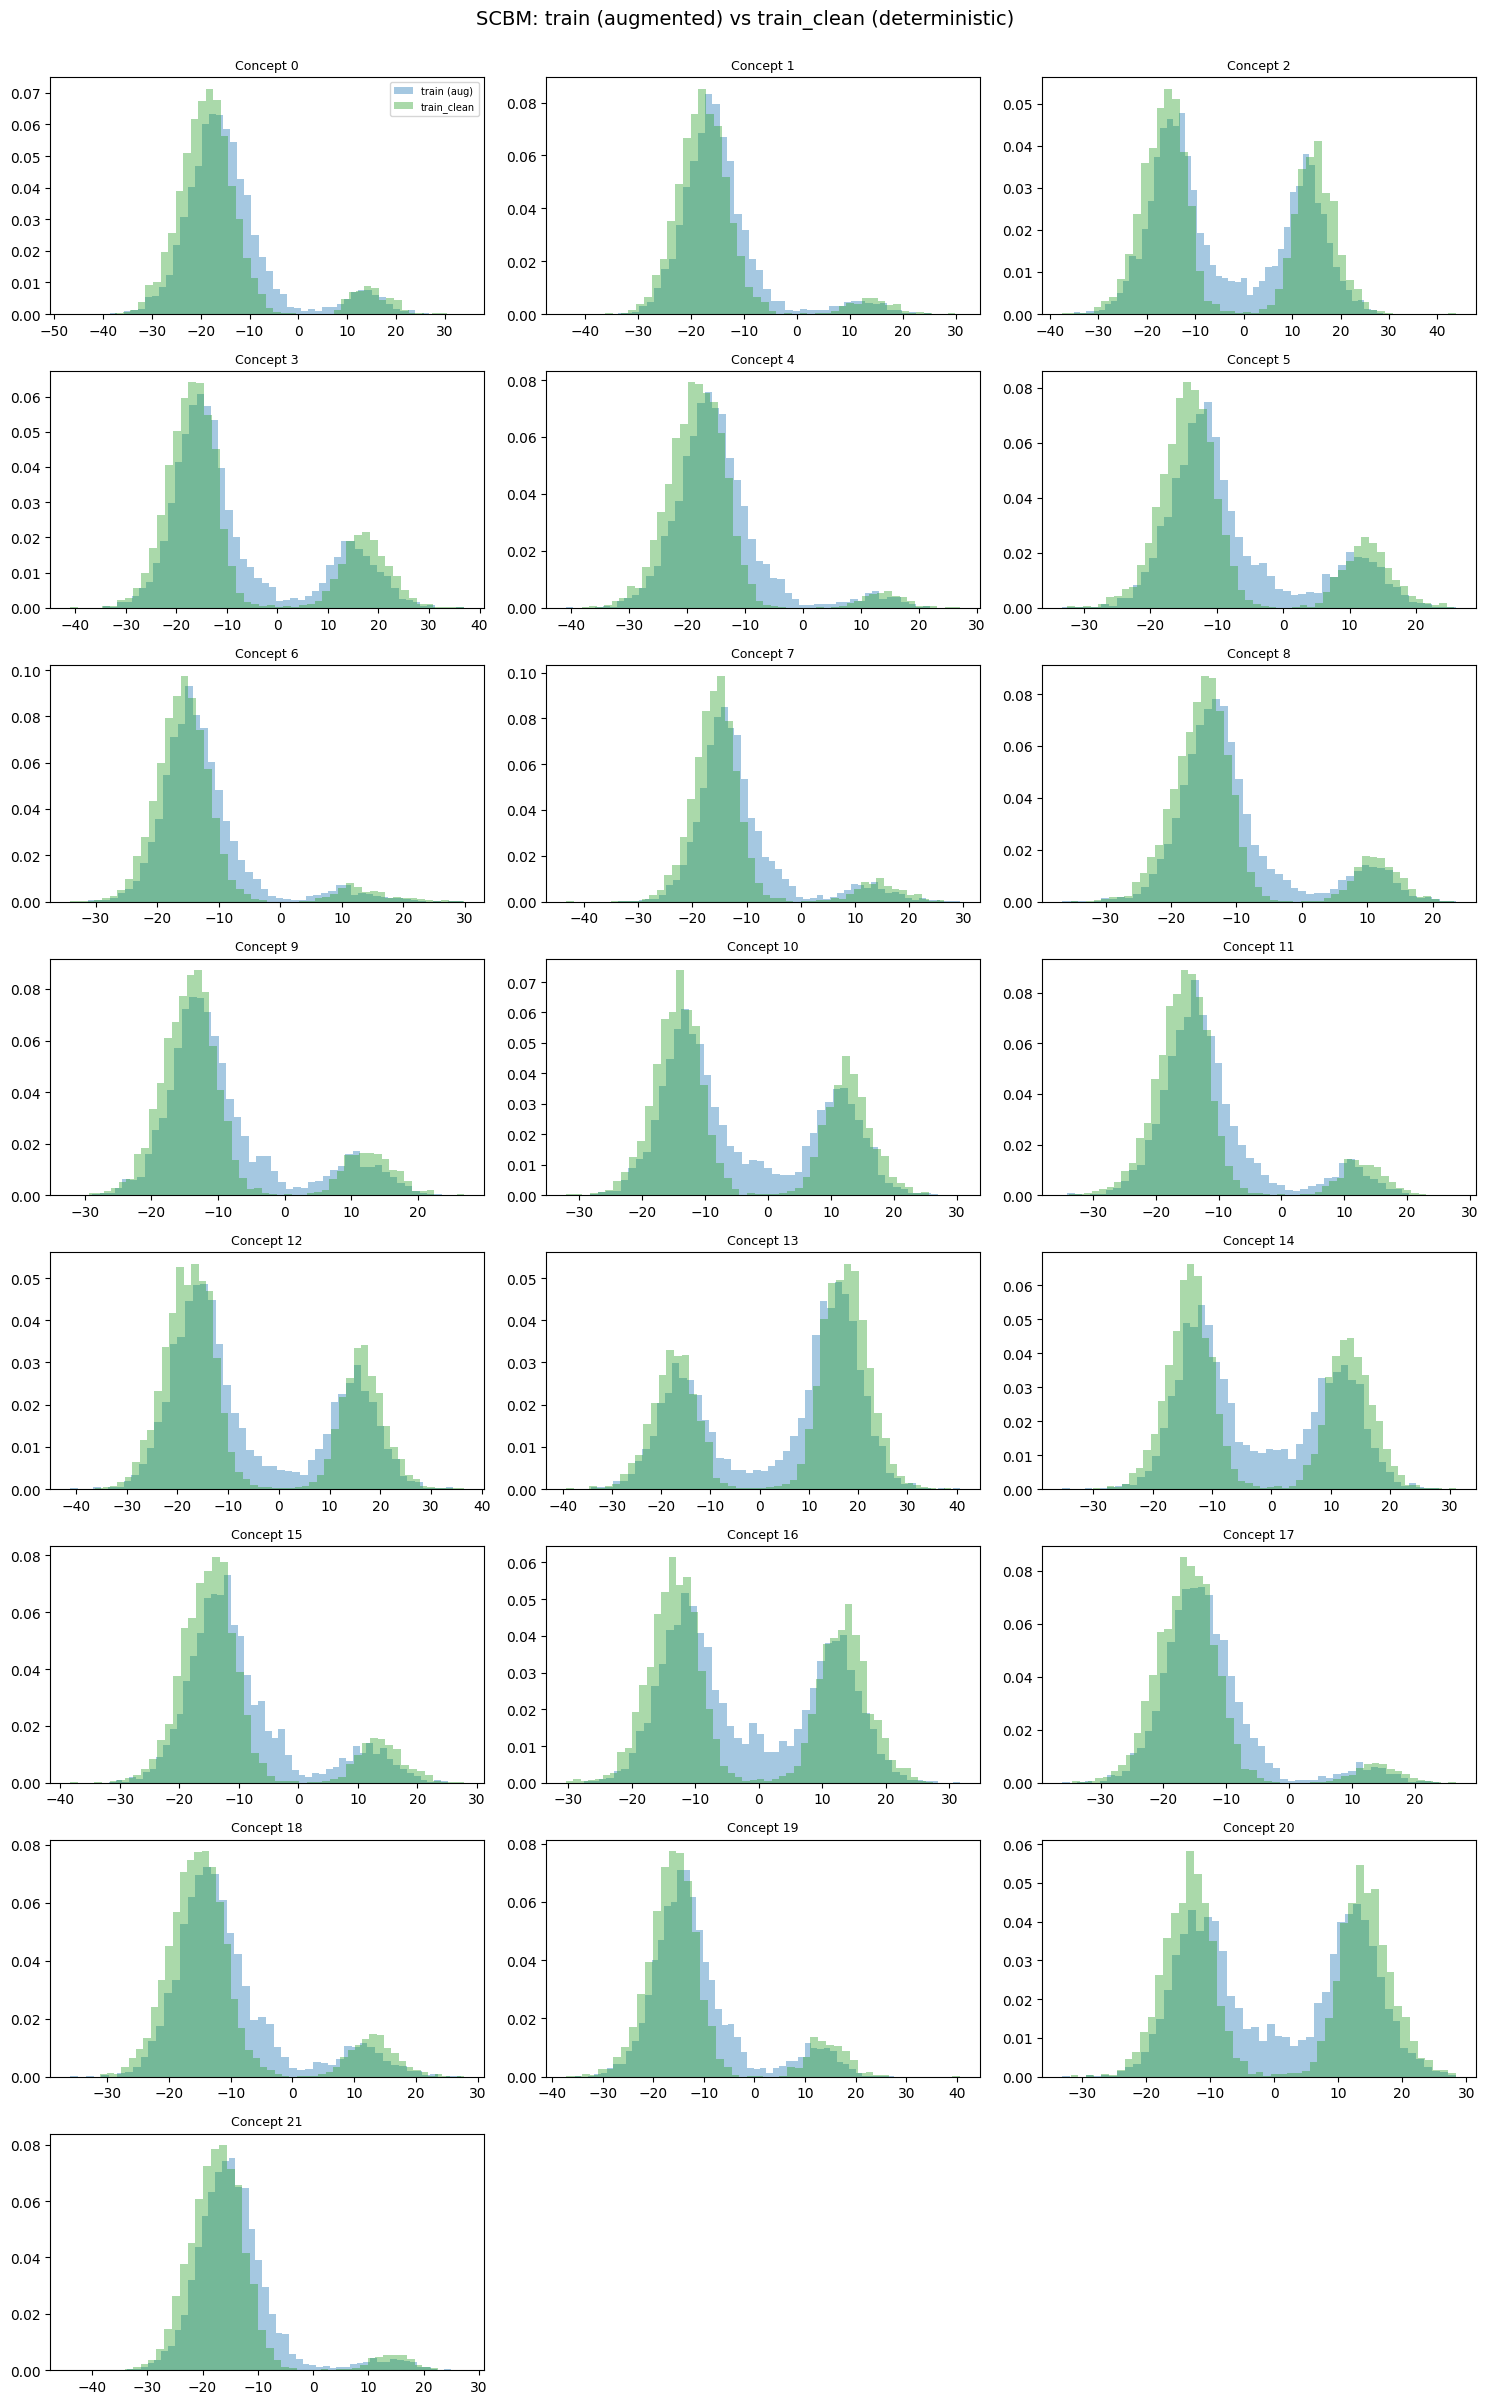

In [34]:
# Overlaid histograms: train (augmented) vs train_clean (deterministic), per concept
num_cols = 3
num_rows = math.ceil(num_dims_scbm / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(num_dims_scbm):
    ax = axes[i]
    label = f"Concept {i}"
    ax.hist(scbm_train_aug_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train (aug)", color="tab:blue")
    ax.hist(scbm_train_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train_clean", color="tab:green")
    ax.set_title(label, fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

for ax in axes[num_dims_scbm:]:
    ax.axis("off")

fig.suptitle("SCBM: train (augmented) vs train_clean (deterministic)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

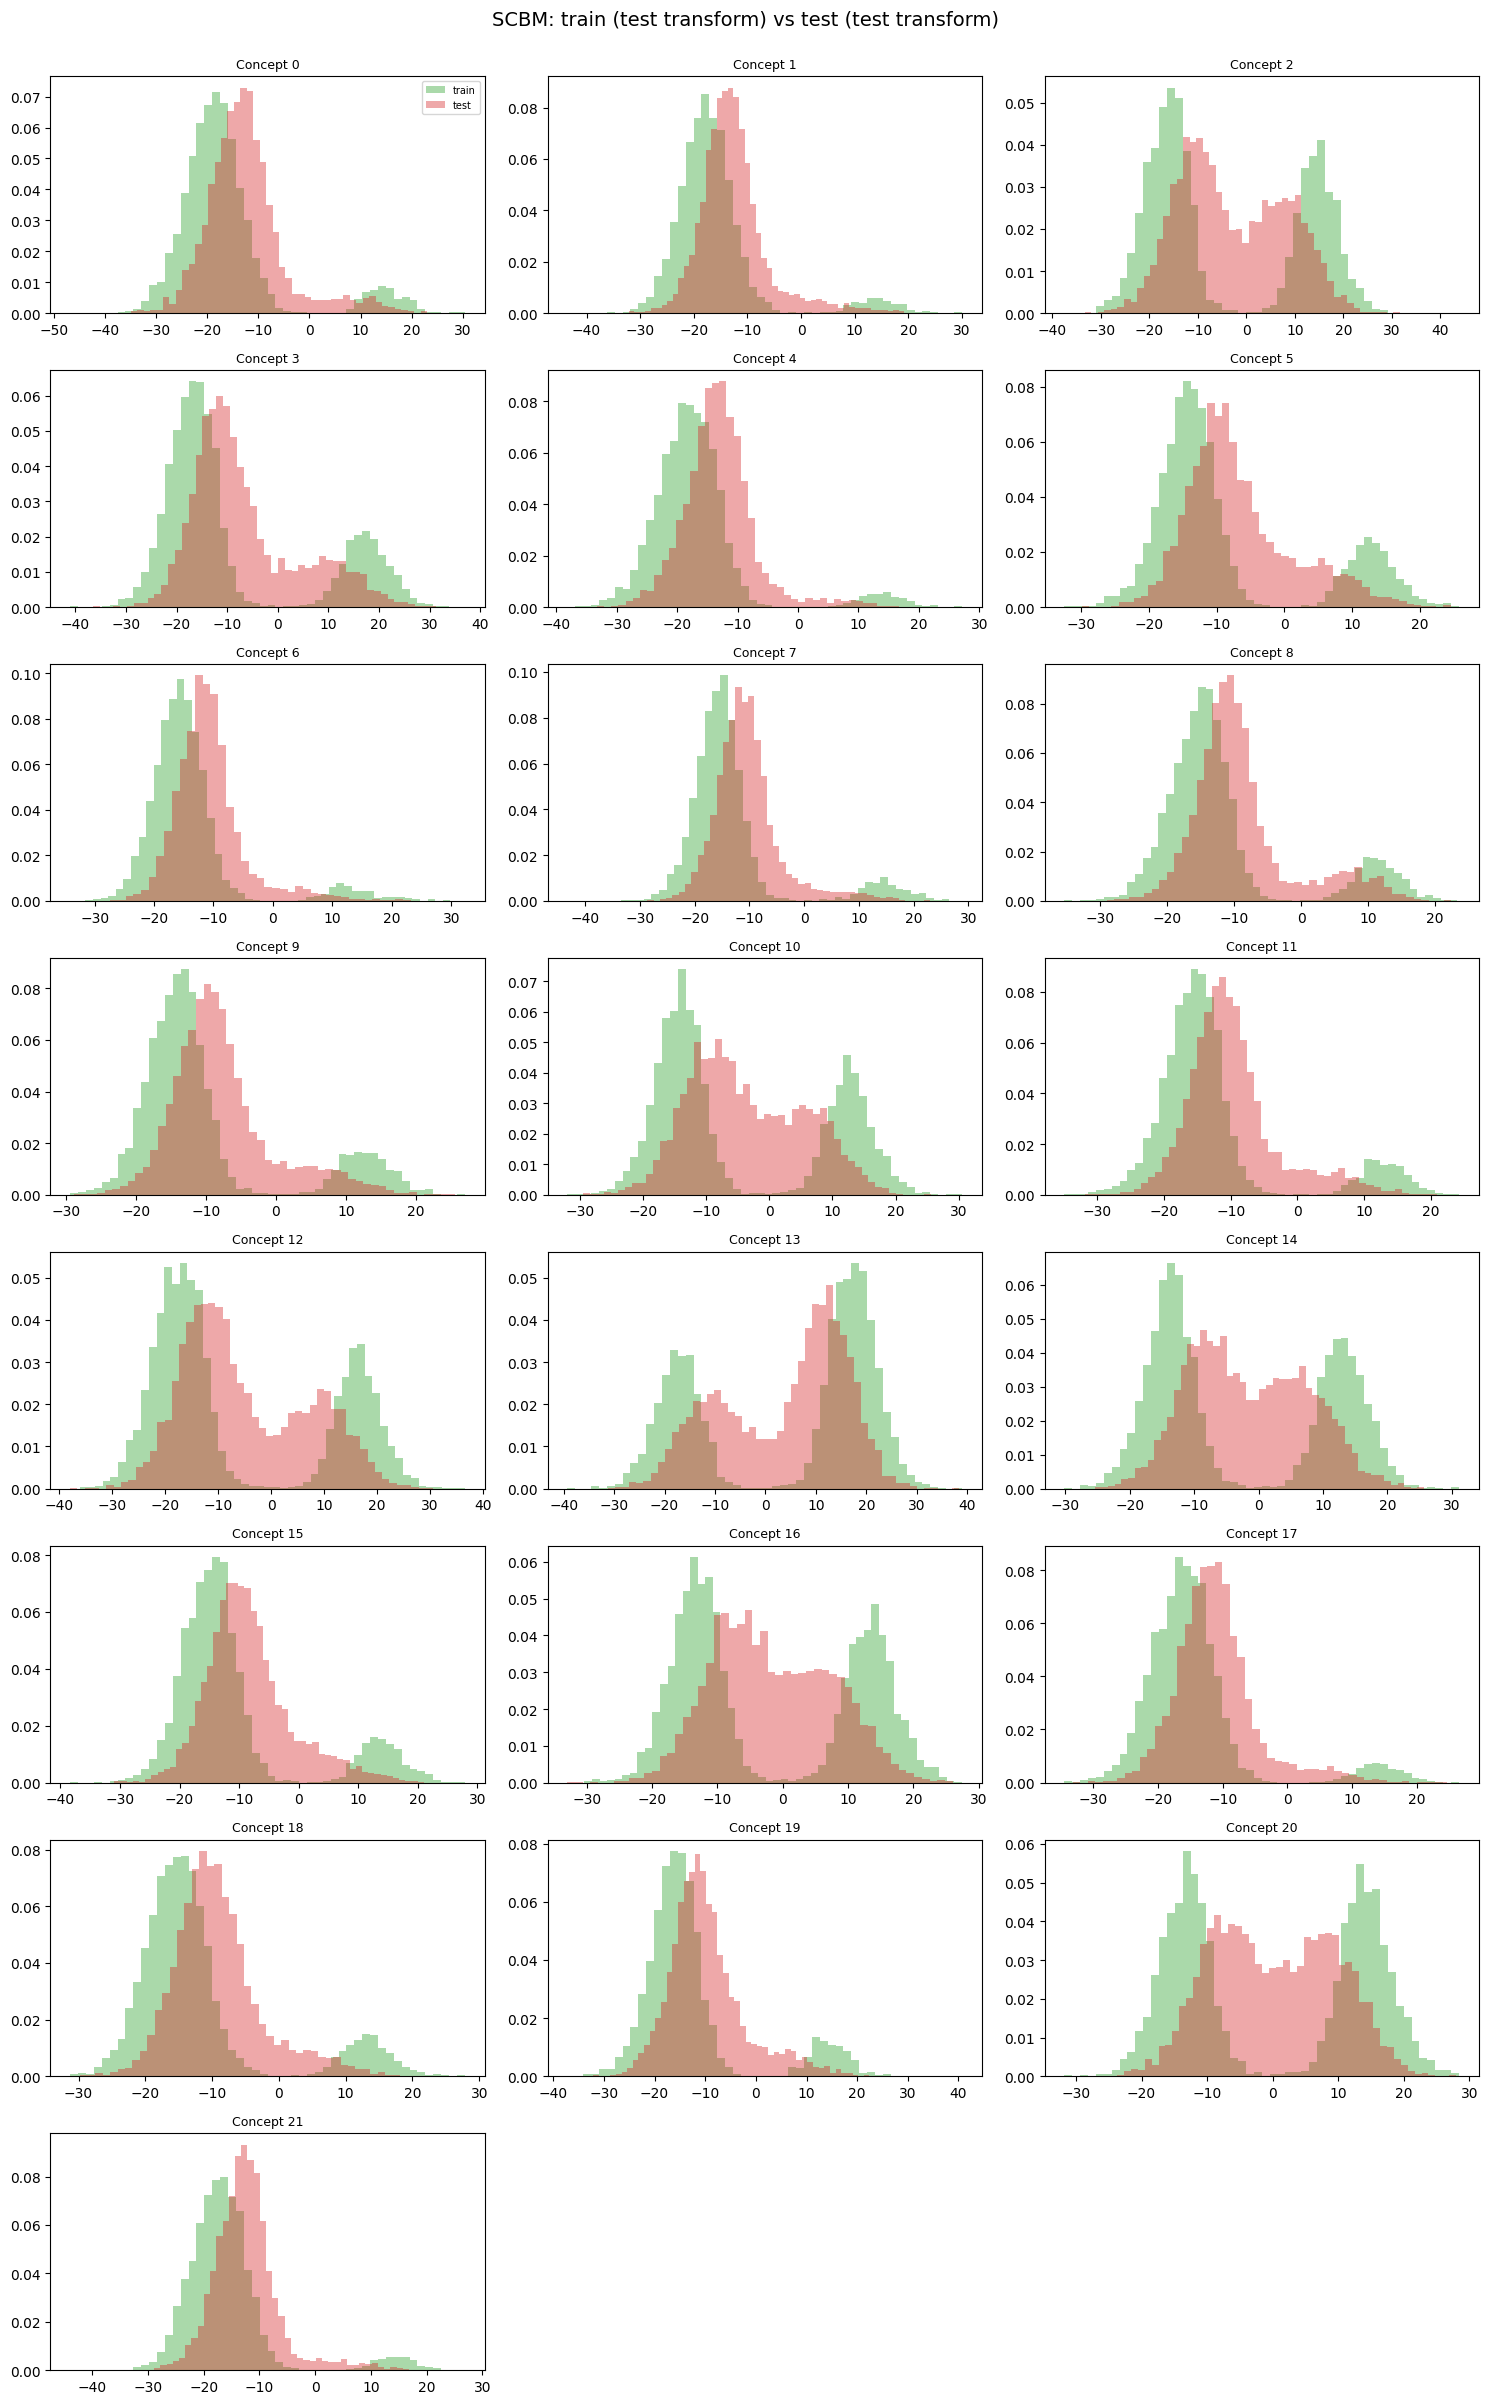

In [35]:
# Overlaid histograms: train_clean (deterministic) vs test, per concept
num_cols = 3
num_rows = math.ceil(num_dims_scbm / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(num_dims_scbm):
    ax = axes[i]
    label = f"Concept {i}"
    ax.hist(scbm_train_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train", color="tab:green")
    ax.hist(scbm_test_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="test", color="tab:red")
    ax.set_title(label, fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

for ax in axes[num_dims_scbm:]:
    ax.axis("off")

fig.suptitle("SCBM: train (test transform) vs test (test transform)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

## Plot train/test/val ground truth distribution

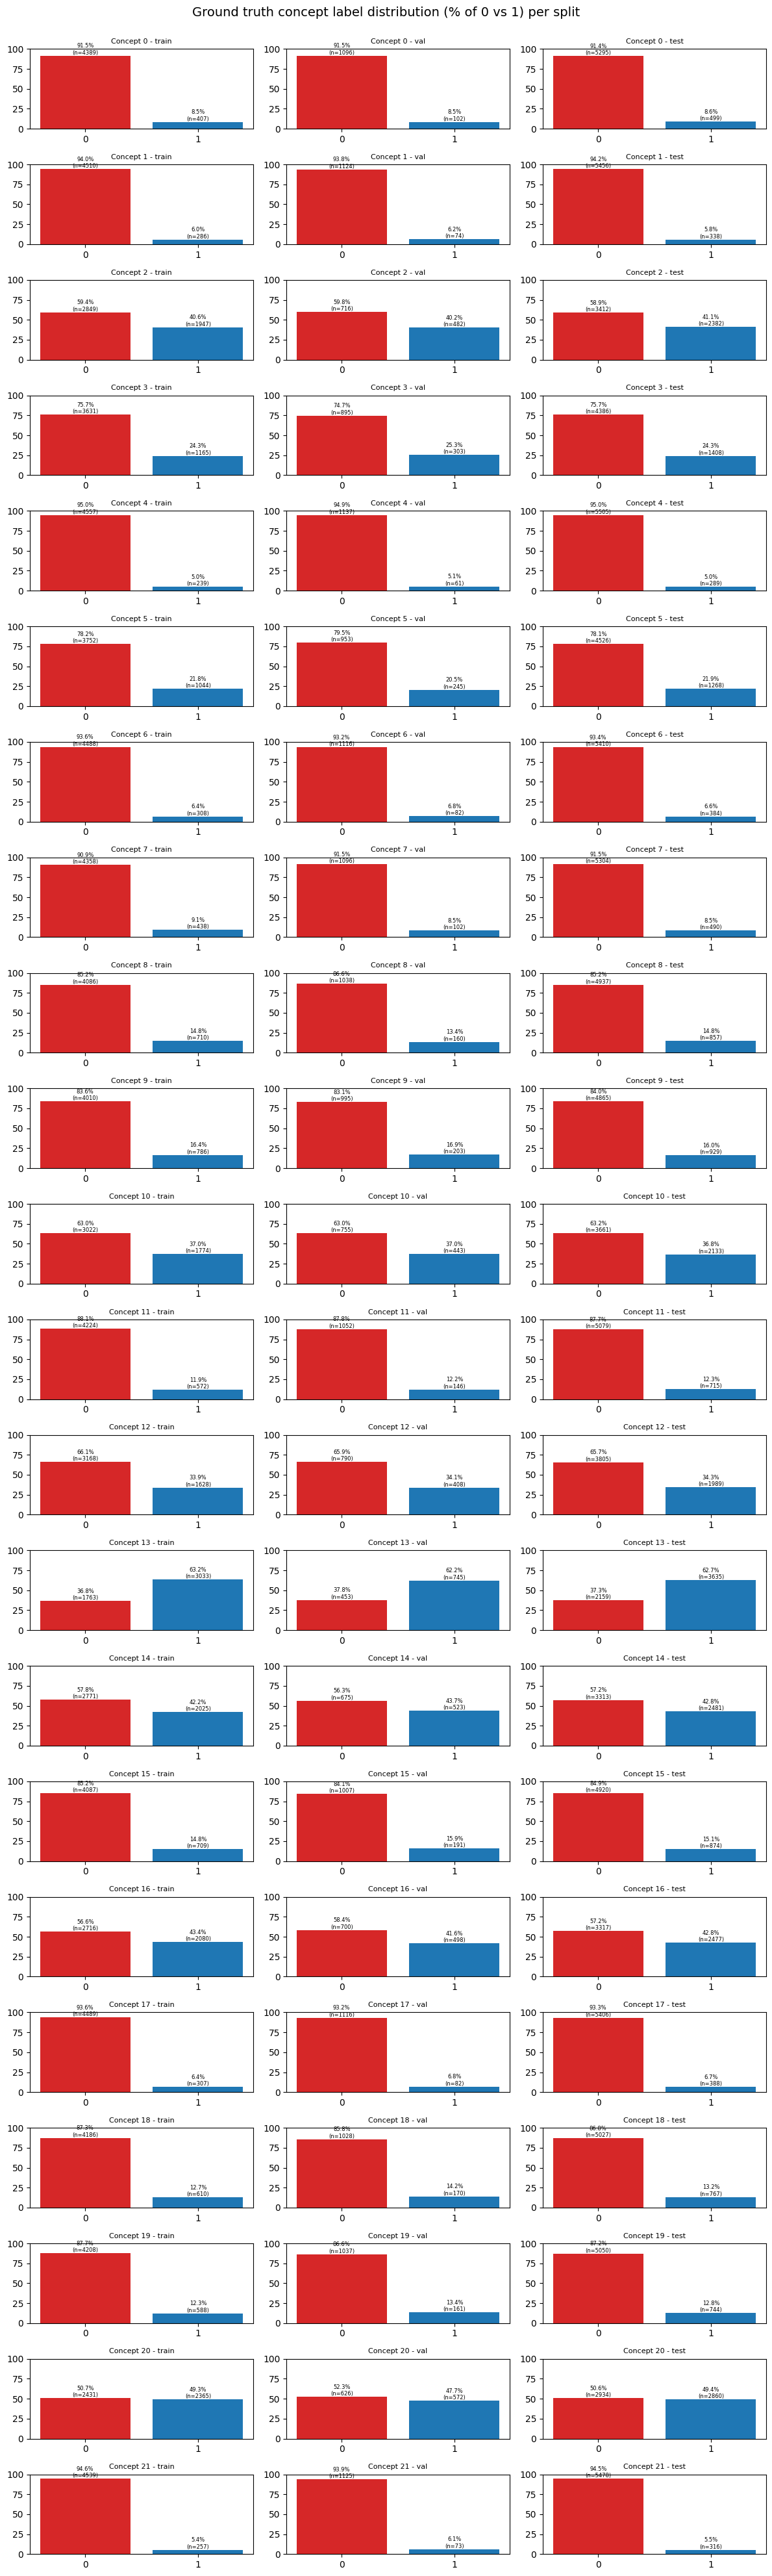

In [38]:
GT_NUM_CONCEPTS = 22
gt_splits = ["train", "val", "test"]

gt_concepts_by_split = {}
for split in gt_splits:
    data_pkl = pd.read_pickle(os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", f"{split}.pkl"))
    gt_concepts_by_split[split] = np.array([sample["attribute_label"] for sample in data_pkl])

fig, axes = plt.subplots(
    GT_NUM_CONCEPTS, len(gt_splits),
    figsize=(4 * len(gt_splits), 1.8 * GT_NUM_CONCEPTS),
)

for row in range(GT_NUM_CONCEPTS):
    for col, split in enumerate(gt_splits):
        ax = axes[row, col]
        c_true = gt_concepts_by_split[split][:, row]
        n = len(c_true)
        num_ones = int(c_true.sum())
        num_zeros = n - num_ones
        pct_zeros = 100 * num_zeros / n
        pct_ones = 100 * num_ones / n
        ax.bar(["0", "1"], [pct_zeros, pct_ones], color=["tab:red", "tab:blue"])
        ax.set_ylim(0, 100)
        ax.set_title(f"Concept {row} - {split}", fontsize=8)
        for x, (pct, count) in enumerate([(pct_zeros, num_zeros), (pct_ones, num_ones)]):
            ax.text(x, pct, f"{pct:.1f}%\n(n={count})", ha="center", va="bottom", fontsize=6)

fig.suptitle("Ground truth concept label distribution (% of 0 vs 1) per split", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

## CBM concept distribution analysis

Baseline Hard CBM trained on the same reduced 22-concept `Mateo_025` CUB dataset as the SCBM/Residual-SCBM runs above, for direct comparison.

Requires the run to have been produced with:
```
python inference.py +model=CBM +data=CUB inference.ex_name=<run_folder_name> \
    run_inference=True incomplete=True data.pkl_file_dir=Mateo_025/ \
    data.num_concepts=22 data.num_classes=200 model.concept_learning=hard \
    data.save_concept_and_residual_channel=True
```
which writes `concepts_pred_probs.pt`, `concepts_logits.pt`, `concepts_sample_mean.pt`, `concepts_sample_std.pt`, `y_pred.pt`, `y_true.pt` per split (`train`, `val`, `test`, `train_with_test_transform`).

In [ ]:
# Update this once the CBM run has been trained + inference has been run with save_concept_and_residual_channel=True
CBM_EXPERIMENT_PATH = os.path.join("experiments", "cbm", "CUB", "<FILL_IN_RUN_FOLDER>")
NUM_CONCEPTS_CBM = 22

In [ ]:
# Load test-split concepts/predictions
split = "test"
cbm_c_probs = torch.load(os.path.join(CBM_EXPERIMENT_PATH, split, "concepts_pred_probs.pt"))
cbm_c_logits = torch.load(os.path.join(CBM_EXPERIMENT_PATH, split, "concepts_logits.pt"))
cbm_c_sample_mean = torch.load(os.path.join(CBM_EXPERIMENT_PATH, split, "concepts_sample_mean.pt"))
cbm_y_true = torch.load(os.path.join(CBM_EXPERIMENT_PATH, split, "y_true.pt"))
cbm_c_binarized = (cbm_c_probs > 0.5).float()

print("cbm_c_probs shape:", cbm_c_probs.shape)
print("cbm_c_logits shape:", cbm_c_logits.shape)

unique_bin, counts_bin = torch.unique(cbm_c_binarized, return_counts=True)
print("Unique binary samples and their counts:")
for u, c in zip(unique_bin, counts_bin):
    print(f"  {u}: {c}")

### Distributions of concept probabilities and logits

In [ ]:
import matplotlib.pyplot as plt
import math

num_cols = 3
num_rows = math.ceil(NUM_CONCEPTS_CBM / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(NUM_CONCEPTS_CBM):
    ax = axes[i]
    name = concept_names_new_idx_map.get(i, f"Concept {i}")
    ax.hist(cbm_c_probs[:, i].numpy(), bins=50, range=(0, 1), color="tab:blue")
    ax.set_title(f"{i}: {name}", fontsize=8)

for ax in axes[NUM_CONCEPTS_CBM:]:
    ax.axis("off")

fig.suptitle(f"CBM: distribution of predicted concept probabilities ({split} split)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Logit distributions, annotated with each concept's activation rate (fraction of samples with prob > 0.5)
activation_rates_cbm = cbm_c_binarized.mean(dim=0)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(NUM_CONCEPTS_CBM):
    ax = axes[i]
    name = concept_names_new_idx_map.get(i, f"Concept {i}")
    ax.hist(cbm_c_logits[:, i].numpy(), bins=50, color="tab:blue")
    ax.set_title(f"{i}: {name}", fontsize=8)
    ax.text(
        0.98, 0.95,
        f"active: {activation_rates_cbm[i].item():.2%}",
        transform=ax.transAxes,
        ha="right", va="top", fontsize=8,
    )

for ax in axes[NUM_CONCEPTS_CBM:]:
    ax.axis("off")

fig.suptitle(f"CBM: distribution of concept logits ({split} split)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

### Correlation matrix and per-concept summary statistics

In [ ]:
import seaborn as sns

corr_matrix_cbm = torch.corrcoef(cbm_c_logits.t())

plt.figure(figsize=(8, 7))
sns.heatmap(corr_matrix_cbm, annot=False, cmap="coolwarm", center=0)
plt.title(f"CBM: concept logit correlation matrix ({split} split)")
plt.xlabel("Concept")
plt.ylabel("Concept")
plt.show()

In [ ]:
def calculate_entropy(probs):
    probs = torch.clamp(probs, min=1e-10, max=1 - 1e-10)
    return -torch.sum(probs * torch.log(probs) + (1 - probs) * torch.log(1 - probs), dim=0)

entropy_values_cbm = calculate_entropy(cbm_c_probs)
variance_logits_cbm = torch.var(cbm_c_logits, dim=0)
active_counts_cbm = torch.sum(cbm_c_binarized, dim=0)
inactive_counts_cbm = cbm_c_binarized.shape[0] - active_counts_cbm
ratio_active_cbm = active_counts_cbm / (active_counts_cbm + inactive_counts_cbm + 1e-10)

data = []
for i in range(NUM_CONCEPTS_CBM):
    most_corr_order = torch.argsort(corr_matrix_cbm[i].abs(), descending=True)
    most_corr_other = next(j.item() for j in most_corr_order if j.item() != i)
    data.append({
        "concept": f"{i}: {concept_names_new_idx_map.get(i, '')}",
        "entropy": entropy_values_cbm[i].item(),
        "variance logits": variance_logits_cbm[i].item(),
        "active_count": active_counts_cbm[i].item(),
        "inactive_count": inactive_counts_cbm[i].item(),
        "ratio_active": ratio_active_cbm[i].item(),
        "most correlated concept": most_corr_other,
        "correlation value": corr_matrix_cbm[i, most_corr_other].item(),
    })

df_cbm = pd.DataFrame(data)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
display(df_cbm)

### Concept activation by class

In [ ]:
class_names_cbm = list(range(200))
df_dims_cbm = pd.DataFrame(cbm_c_probs.numpy(), columns=list(range(NUM_CONCEPTS_CBM)))
df_dims_cbm["class"] = cbm_y_true.numpy()
class_means_cbm = df_dims_cbm.groupby("class").mean()
class_means_cbm.index = [class_names_cbm[i] for i in class_means_cbm.index]

plt.figure(figsize=(10, 42))
sns.heatmap(
    class_means_cbm,
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "mean predicted probability"},
)
plt.title(f"CBM: mean concept activation probability per class ({split} split)")
plt.xlabel("Concept")
plt.ylabel("Class")
plt.xticks(fontsize=7)
plt.yticks(fontsize=5)
plt.tight_layout()
plt.show()

In [ ]:
# Zoomed-in heatmap for a chosen subset of classes (edit CLASSES_TO_SHOW_CBM)
CLASSES_TO_SHOW_CBM = class_names_cbm[:15]

plt.figure(figsize=(10, max(4, 0.4 * len(CLASSES_TO_SHOW_CBM))))
sns.heatmap(
    class_means_cbm.loc[CLASSES_TO_SHOW_CBM],
    cmap="viridis",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 6},
    cbar_kws={"label": "mean predicted probability"},
)
plt.title("CBM: mean concept activation probability (selected classes)")
plt.xlabel("Concept")
plt.ylabel("Class")
plt.xticks(fontsize=7)
plt.tight_layout()
plt.show()

### Train (augmented) vs train (clean) vs test logit distribution comparison

Same augmentation-shift check as the SCBM plots above: `train` logits are computed with training-time augmentation, `train_with_test_transform` with the deterministic test-time transform on the same images, so any spread between the two isolates the augmentation effect from a genuine train/test distribution shift.

In [ ]:
cbm_train_aug_logits = torch.load(os.path.join(CBM_EXPERIMENT_PATH, "train", "concepts_logits.pt"))
cbm_train_clean_logits = torch.load(os.path.join(CBM_EXPERIMENT_PATH, "train_with_test_transform", "concepts_logits.pt"))
cbm_test_clean_logits = torch.load(os.path.join(CBM_EXPERIMENT_PATH, "test", "concepts_logits.pt"))

print("train (augmented):", cbm_train_aug_logits.shape, "mean", cbm_train_aug_logits.mean().item(), "std", cbm_train_aug_logits.std().item())
print("train_clean (deterministic):", cbm_train_clean_logits.shape, "mean", cbm_train_clean_logits.mean().item(), "std", cbm_train_clean_logits.std().item())
print("test (deterministic):", cbm_test_clean_logits.shape, "mean", cbm_test_clean_logits.mean().item(), "std", cbm_test_clean_logits.std().item())

In [ ]:
# Overlaid histograms: train (augmented) vs train_clean (deterministic), per concept
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(NUM_CONCEPTS_CBM):
    ax = axes[i]
    name = concept_names_new_idx_map.get(i, f"Concept {i}")
    ax.hist(cbm_train_aug_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train (aug)", color="tab:blue")
    ax.hist(cbm_train_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train_clean", color="tab:green")
    ax.set_title(f"{i}: {name}", fontsize=8)
    if i == 0:
        ax.legend(fontsize=7)

for ax in axes[NUM_CONCEPTS_CBM:]:
    ax.axis("off")

fig.suptitle("CBM: train (augmented) vs train_clean (deterministic)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Overlaid histograms: train_clean (deterministic) vs test, per concept
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(NUM_CONCEPTS_CBM):
    ax = axes[i]
    name = concept_names_new_idx_map.get(i, f"Concept {i}")
    ax.hist(cbm_train_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train", color="tab:green")
    ax.hist(cbm_test_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="test", color="tab:red")
    ax.set_title(f"{i}: {name}", fontsize=8)
    if i == 0:
        ax.legend(fontsize=7)

for ax in axes[NUM_CONCEPTS_CBM:]:
    ax.axis("off")

fig.suptitle("CBM: train (test transform) vs test (test transform)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()